In [1]:
import pandas as pd

# Data laden
df = pd.read_parquet('preprocessed_custom_data.parquet')

In [2]:
# Nur numerische Spalten betrachten
numeric_df = df.select_dtypes(include='number')

# Counter-Heuristik
counter_features = []
threshold = 0.95  # 95% der Werte steigen oder bleiben gleich

In [3]:
for col in numeric_df.columns:
    diffs = numeric_df[col].diff().dropna()
    non_decreasing_ratio = (diffs >= 0).mean()

    if non_decreasing_ratio >= threshold:
        counter_features.append(col)

# Delta-Werte berechnen und Originalspalten ersetzen
for col in counter_features:
    df[col] = df[col].diff().fillna(0)

In [4]:
print(f"\nErsetzte Counter-Features durch Delta-Werte ({len(counter_features)}):")
for feat in counter_features:
    print(f"'{feat}',")


Ersetzte Counter-Features durch Delta-Werte (811):
'cpu-migrations',
'exc_undef',
'l2d_cache_wb_clean',
'strex_fail_spec',
'alarmtimer_alarmtimer_cancel',
'alarmtimer_alarmtimer_fired',
'alarmtimer_alarmtimer_start',
'alarmtimer_alarmtimer_suspend',
'alignment-faults',
'block_block_bio_backmerge',
'block_block_bio_bounce',
'block_block_bio_complete',
'block_block_bio_frontmerge',
'block_block_bio_queue',
'block_block_bio_remap',
'block_block_dirty_buffer',
'block_block_getrq',
'block_block_plug',
'block_block_rq_complete',
'block_block_rq_insert',
'block_block_rq_issue',
'block_block_rq_merge',
'block_block_rq_remap',
'block_block_rq_requeue',
'block_block_split',
'block_block_touch_buffer',
'block_block_unplug',
'bpf-output',
'bus_access_shared',
'cid_write_retired',
'clk_clk_disable',
'clk_clk_disable_complete',
'clk_clk_enable',
'clk_clk_enable_complete',
'clk_clk_prepare',
'clk_clk_prepare_complete',
'clk_clk_set_duty_cycle',
'clk_clk_set_duty_cycle_complete',
'clk_clk_set_max_rat

In [5]:
# ab Zeile 6690 ist noise in den daten

df = df.iloc[:6690]

In [6]:
df.head(-1)

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T18:00:00,842.0,534639.0,114176.0,14852.0,648716.0,95435.0,15470.0,657359.0,16248.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,benign
1,2025-07-22T18:00:10,830.0,530504.0,113038.0,14845.0,643445.0,94416.0,14958.0,649089.0,15080.0,...,2.0,2.0,12.0,0.0,0.0,0.0,2.0,12.0,benign,benign
2,2025-07-22T18:00:20,775.0,530791.0,113318.0,15235.0,644009.0,94677.0,16126.0,678009.0,14637.0,...,3.0,3.0,13.0,0.0,0.0,0.0,3.0,13.0,benign,benign
3,2025-07-22T18:00:30,895.0,533606.0,113935.0,14633.0,647442.0,95136.0,15474.0,646697.0,14399.0,...,3.0,3.0,11.0,0.0,0.0,0.0,2.0,11.0,benign,benign
4,2025-07-22T18:00:40,822.0,536215.0,114003.0,15363.0,650120.0,95225.0,14512.0,640024.0,14608.0,...,2.0,2.0,11.0,0.0,0.0,0.0,2.0,11.0,benign,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6684,2025-07-23T12:34:00,802.0,538076.0,114510.0,15062.0,652486.0,95618.0,14769.0,640186.0,15394.0,...,3.0,3.0,16.0,0.0,0.0,0.0,3.0,16.0,benign,benign
6685,2025-07-23T12:34:10,854.0,541724.0,115780.0,16307.0,657404.0,96743.0,14578.0,647322.0,15075.0,...,3.0,3.0,17.0,0.0,0.0,0.0,3.0,17.0,benign,benign
6686,2025-07-23T12:34:20,767.0,538453.0,115911.0,14974.0,654263.0,96805.0,15306.0,650989.0,15422.0,...,6.0,6.0,18.0,0.0,0.0,0.0,6.0,18.0,benign,benign
6687,2025-07-23T12:34:30,823.0,541888.0,115855.0,15573.0,657644.0,96817.0,14918.0,648631.0,14909.0,...,5.0,5.0,13.0,0.0,0.0,0.0,3.0,13.0,benign,benign


In [7]:
# alle angaben sind schon auf kleinschreibung und das richtige format angepasst
intervals = [
    ("2025-07-23T06:52:35.000", "2025-07-23T07:07:35.000", "slowloris"),
    ("2025-07-23T07:27:35.000", "2025-07-23T07:42:35.000", "udpflood"),
    ("2025-07-23T08:25:45.000", "2025-07-23T08:47:50.000", "icmpflood"),
    ("2025-07-23T08:50:49.000", "2025-07-23T09:05:49.000", "tcpflood"),
    ("2025-07-23T09:05:49.000", "2025-07-23T09:08:49.000", "synonymousflood"),
    ("2025-07-23T09:10:44.000", "2025-07-23T09:20:44.000", "portscan"),
    ("2025-07-23T09:35:44.000", "2025-07-23T09:45:44.000", "synonymousflood"),
    ("2025-07-23T10:00:44.000", "2025-07-23T10:10:44.000", "osfingerprinting"),
    ("2025-07-23T10:25:44.000", "2025-07-23T10:35:44.000", "aggressivescan"),
    ("2025-07-23T10:50:44.000", "2025-07-23T11:00:44.000", "slowloris"),
    ("2025-07-23T11:10:21.000", "2025-07-23T11:18:21.000", "udpflood"),
    ("2025-07-23T11:28:21.000", "2025-07-23T11:36:21.000", "icmpflood"),
    ("2025-07-23T11:46:21.000", "2025-07-23T11:54:21.000", "tcpflood"),
    ("2025-07-23T12:08:55.000", "2025-07-23T12:12:21.000", "portscan"),
    ("2025-07-23T12:22:21.000", "2025-07-23T12:30:21.000", "synonymousflood"),
]

for start, end, value in intervals:
    maske = (df["timestamp"] >= start) & (df["timestamp"] <= end)
    df.loc[maske, "attack"] = value
    df.loc[maske, "Label"] = "attack"


In [8]:
df["attack"] = df["attack"].fillna("benign")
df["Label"]  = df["Label"].fillna("benign")

In [9]:
# Fehlende Werte pro Spalte (Top 20)
df.isnull().sum().sort_values(ascending=False).head(20)

Label                            0
timestamp                        0
ase_spec                         0
br_immed_spec                    0
br_indirect_spec                 0
br_mis_pred                      0
br_pred                          0
tcp_tcp_receive_reset            0
tcp_tcp_retransmit_skb           0
tcp_tcp_retransmit_synack        0
tcp_tcp_send_reset               0
udp_udp_fail_queue_rcv_skb       0
writeback_balance_dirty_pages    0
writeback_bdi_dirty_ratelimit    0
writeback_flush_foreign          0
syscalls_sys_exit_write          0
syscalls_sys_exit_writev         0
task_task_newtask                0
task_task_rename                 0
tcp_tcp_bad_csum                 0
dtype: int64

In [10]:
df.head()

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T18:00:00,842.0,534639.0,114176.0,14852.0,648716.0,95435.0,15470.0,657359.0,16248.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,benign
1,2025-07-22T18:00:10,830.0,530504.0,113038.0,14845.0,643445.0,94416.0,14958.0,649089.0,15080.0,...,2.0,2.0,12.0,0.0,0.0,0.0,2.0,12.0,benign,benign
2,2025-07-22T18:00:20,775.0,530791.0,113318.0,15235.0,644009.0,94677.0,16126.0,678009.0,14637.0,...,3.0,3.0,13.0,0.0,0.0,0.0,3.0,13.0,benign,benign
3,2025-07-22T18:00:30,895.0,533606.0,113935.0,14633.0,647442.0,95136.0,15474.0,646697.0,14399.0,...,3.0,3.0,11.0,0.0,0.0,0.0,2.0,11.0,benign,benign
4,2025-07-22T18:00:40,822.0,536215.0,114003.0,15363.0,650120.0,95225.0,14512.0,640024.0,14608.0,...,2.0,2.0,11.0,0.0,0.0,0.0,2.0,11.0,benign,benign


In [11]:
df.to_csv("delta_replaced_data.csv", index=False)

In [12]:
from config_features import FEATURES

top20_features = FEATURES
#plus Features des papers:
top20_features.extend(['instructions', 'cache-misses', 'cpu-migrations', 'dTLB-store-misses', 'l1d_cache_wr', 
                       'L1-icache-loads', 'l2d_cache_rd', 'mem_access_rd', 'mem_access_wr', 'kmem_kfree',
                       'net_net_dev_xmit', 'qdisc_qdisc_dequeue', 'raw_syscalls_sys_enter', 'irq_softirq_raise',
                       'sched_sched_migrate_task', 'sched_sched_switch', 'syscalls_sys_enter_close', 'syscalls_sys_enter_read',
                       'syscalls_sys_enter_write'])

In [13]:
df_subset = df.iloc[5000:]

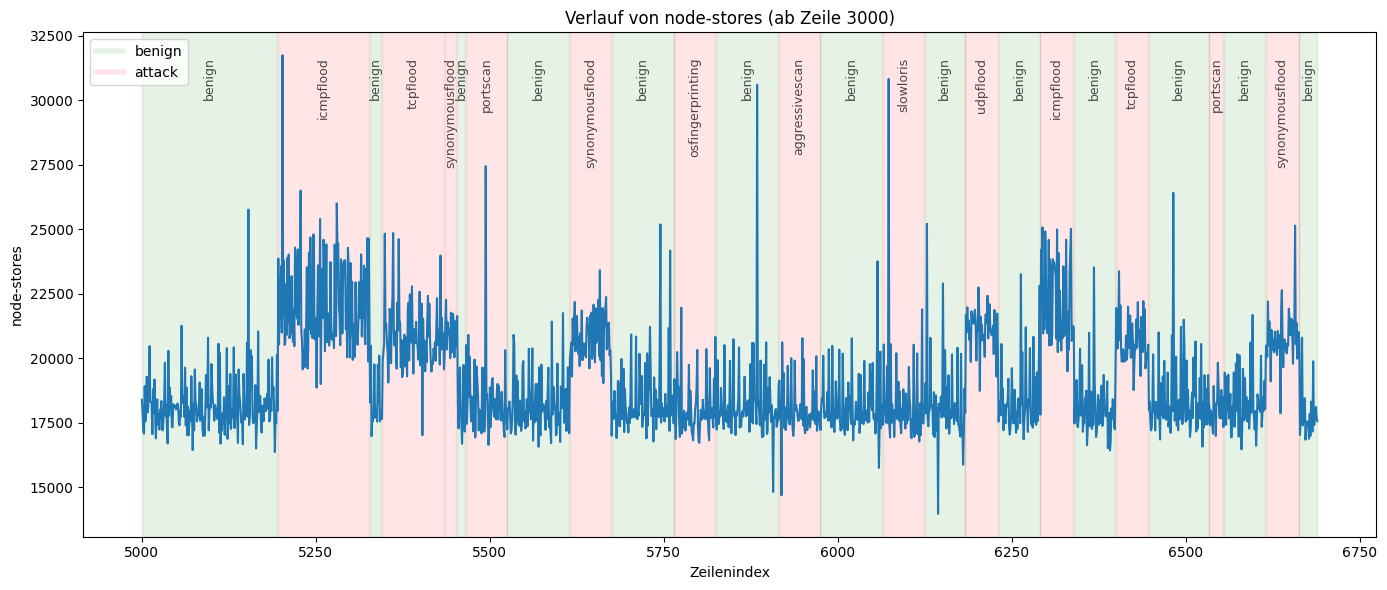

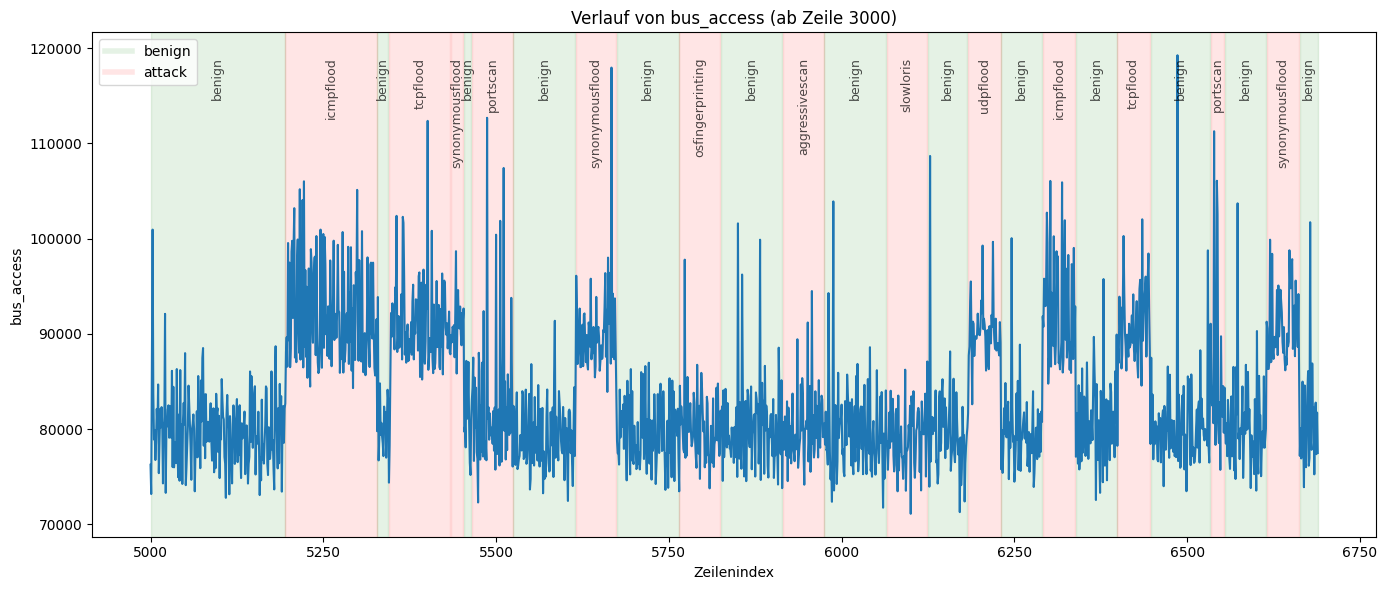

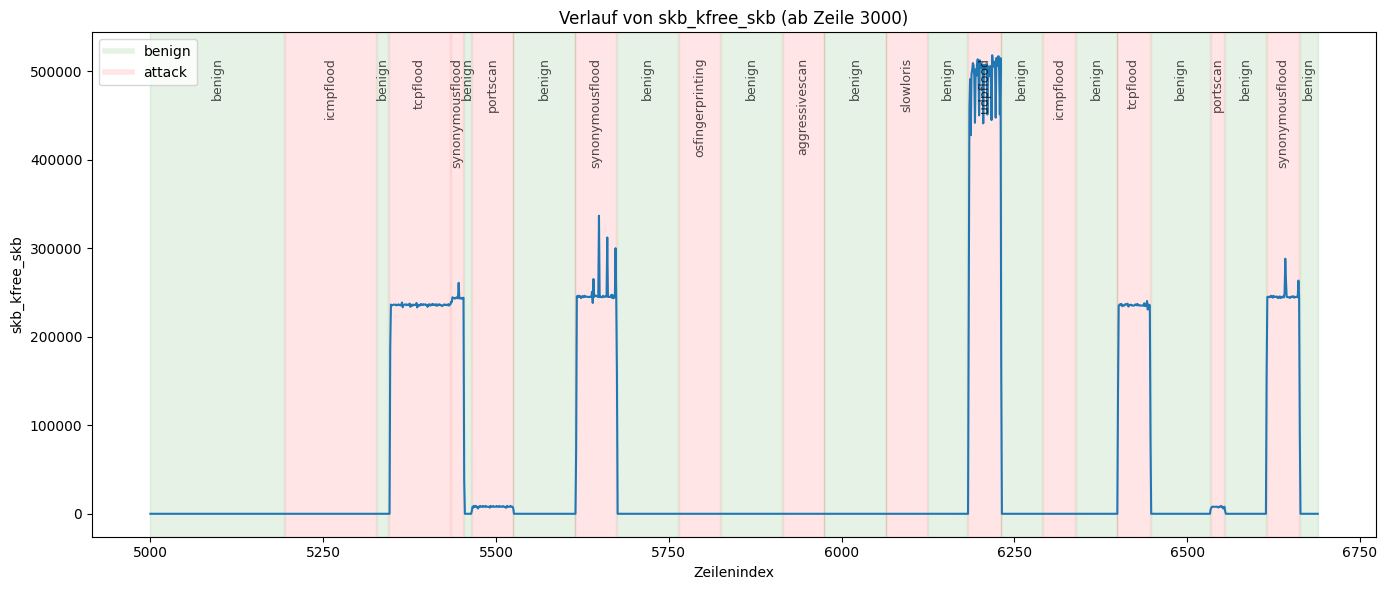

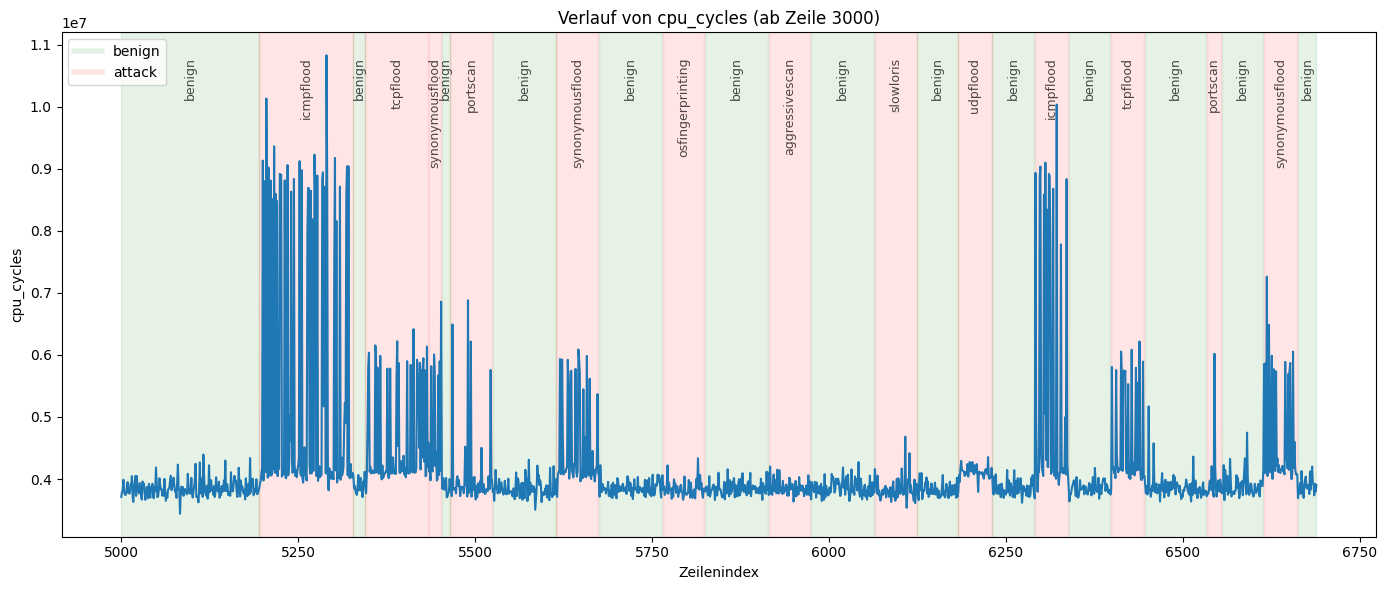

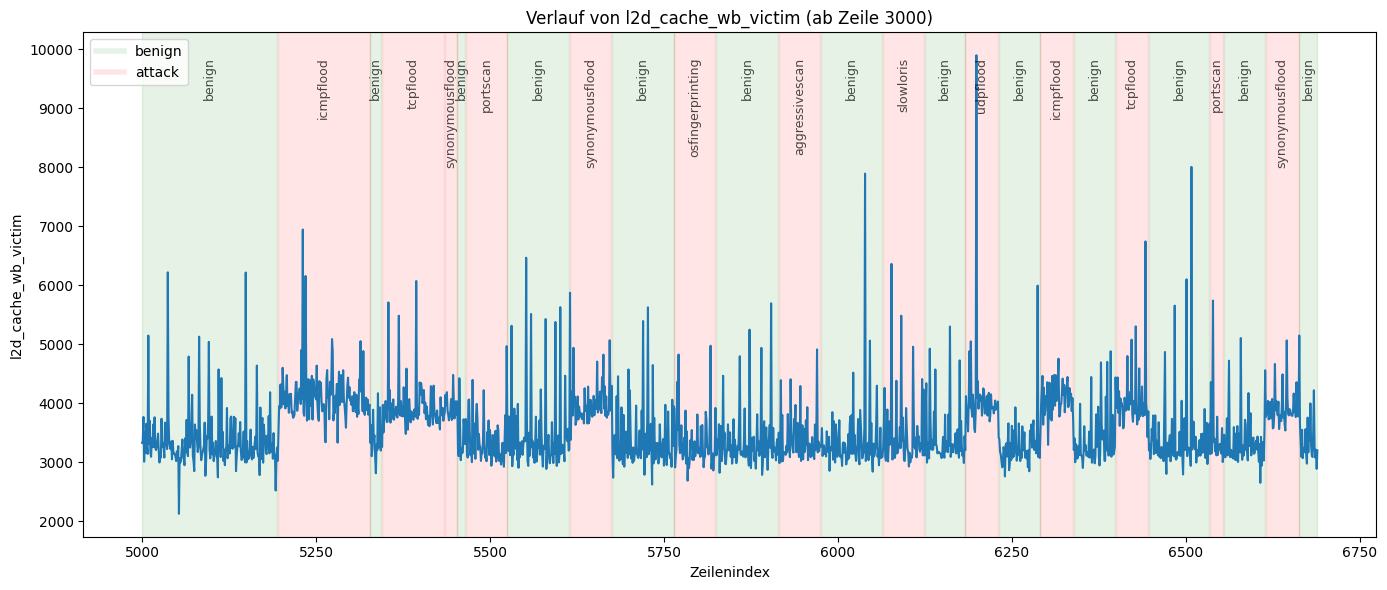

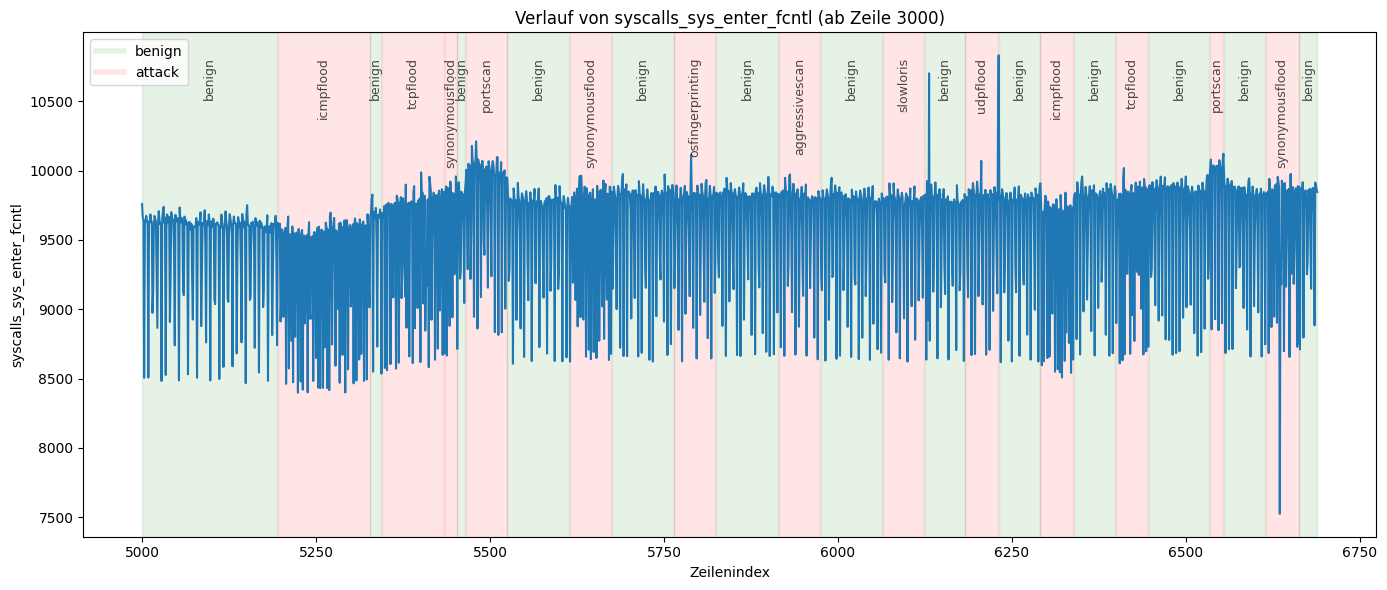

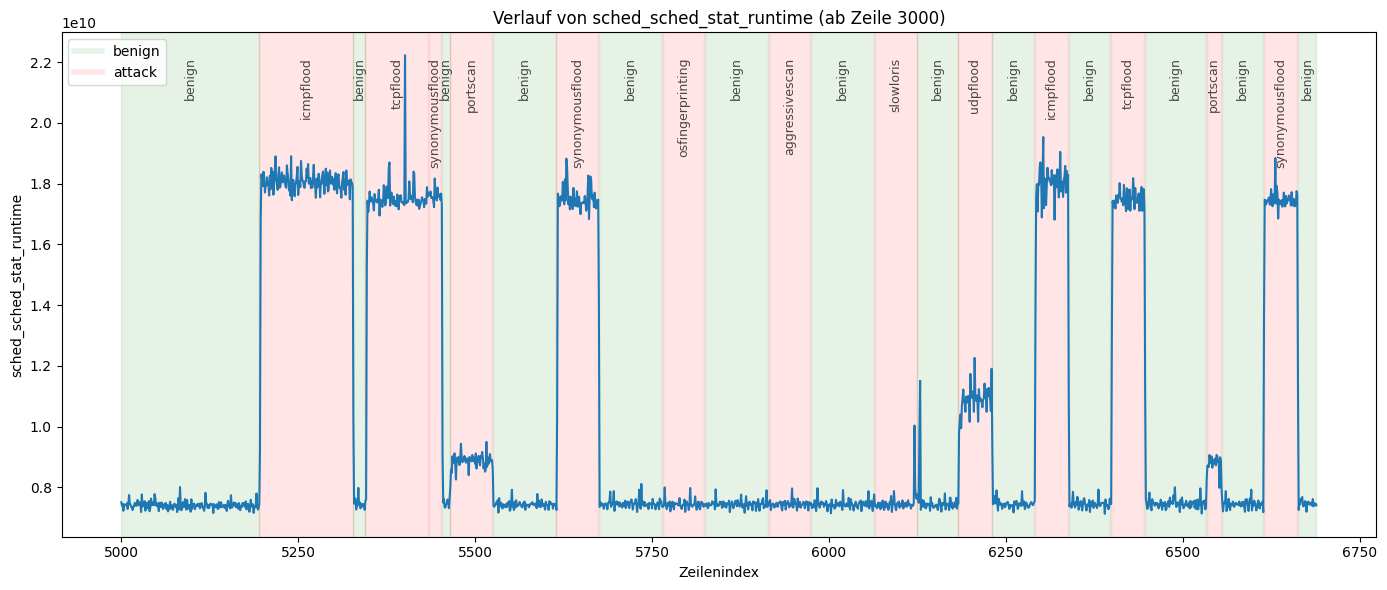

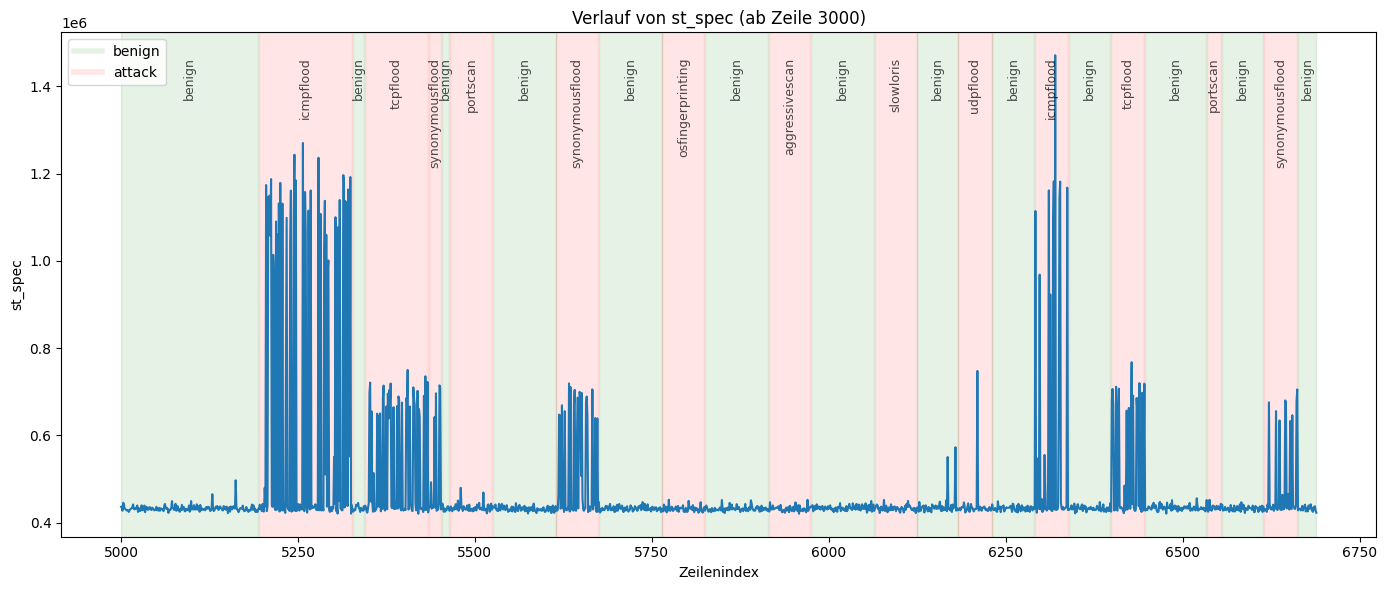

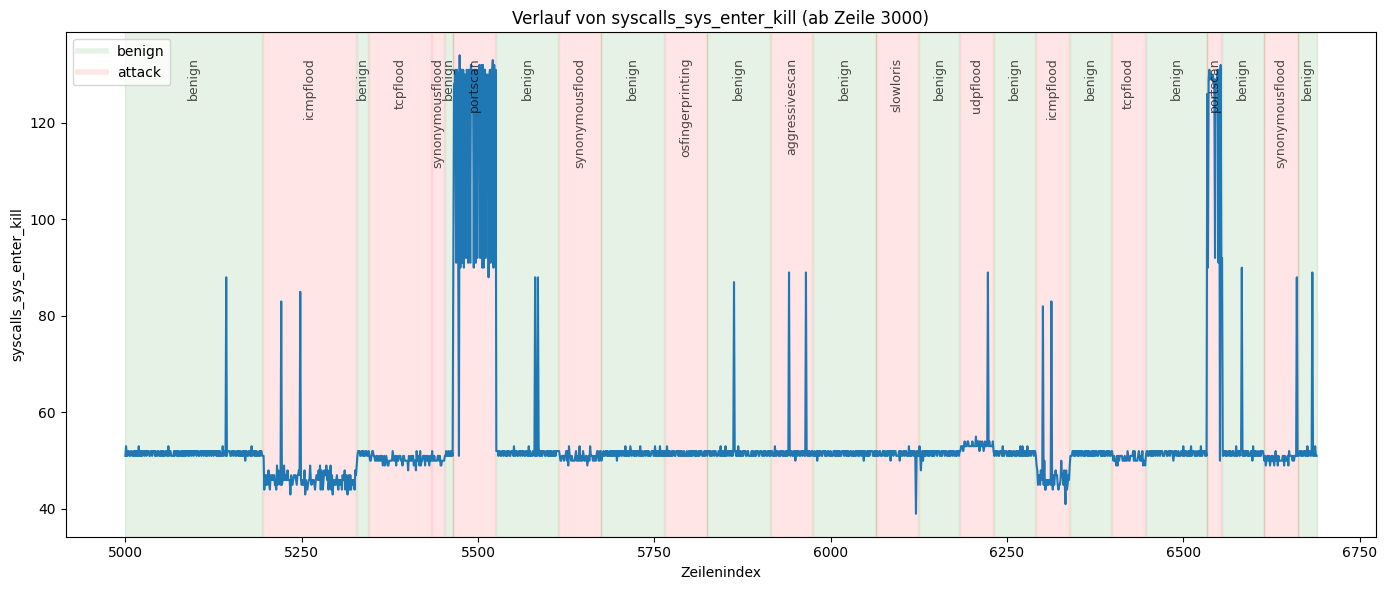

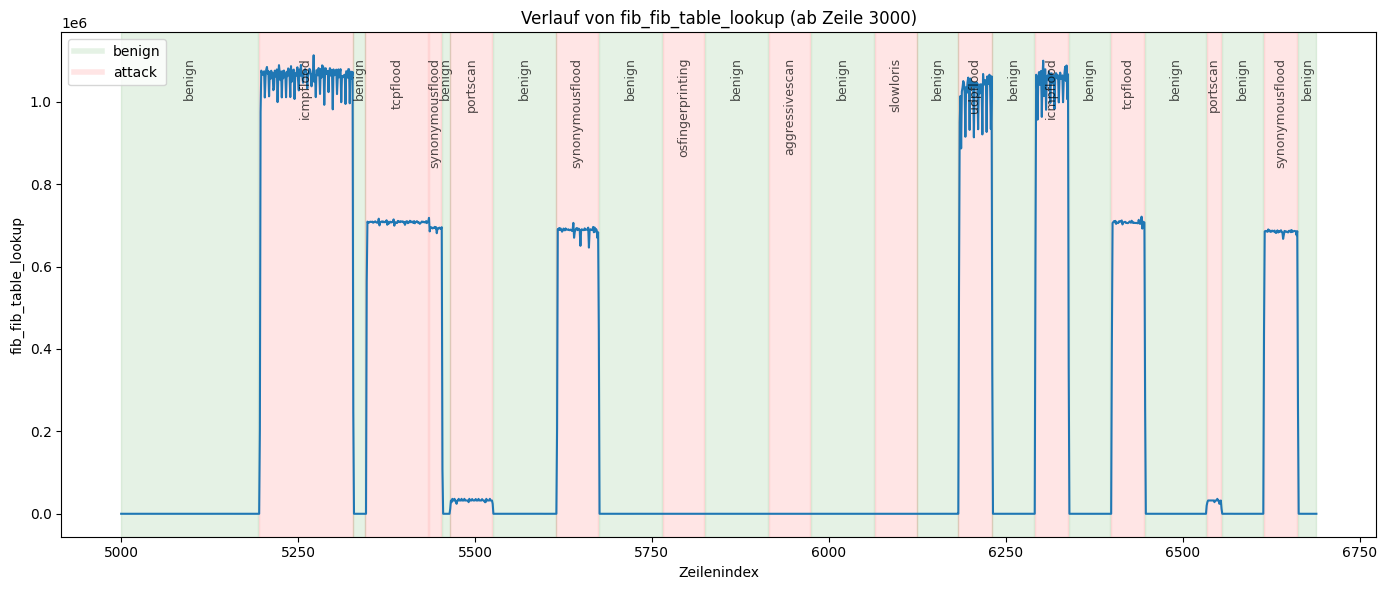

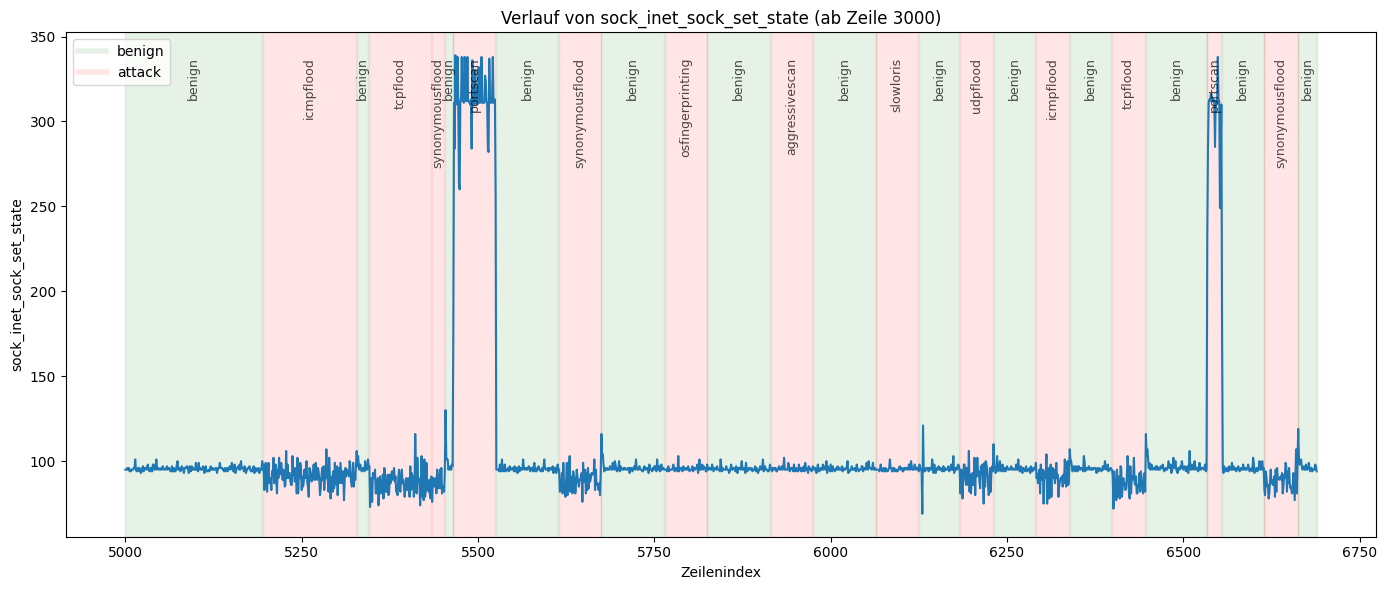

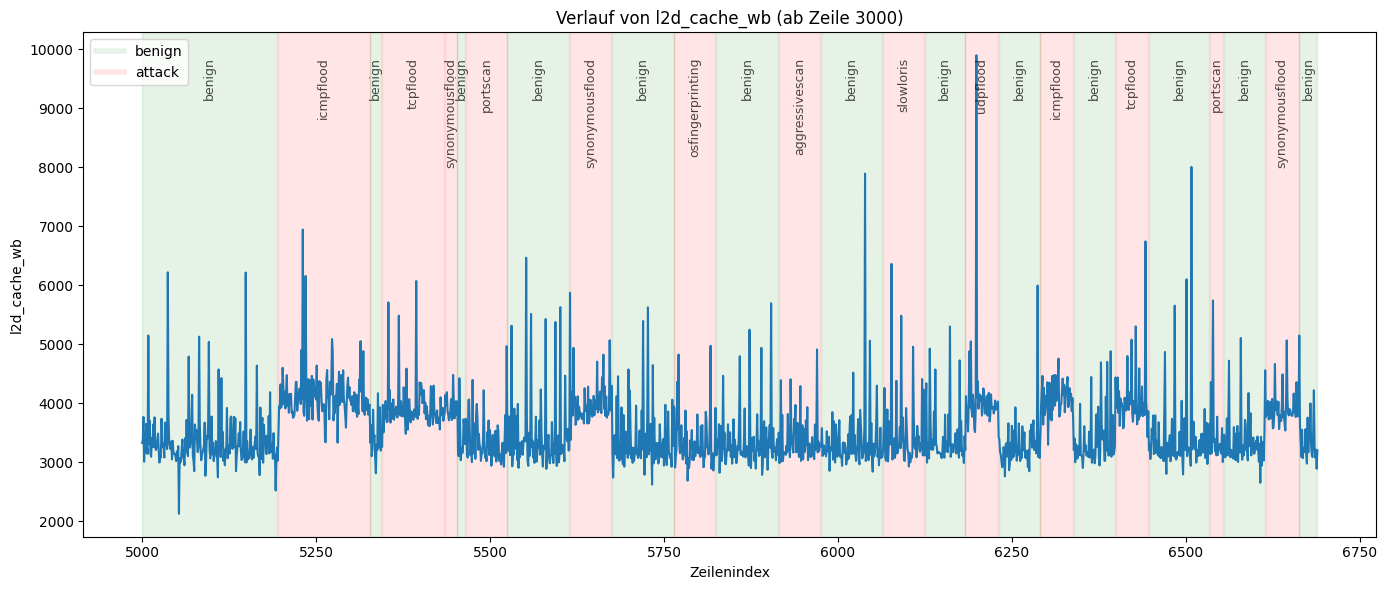

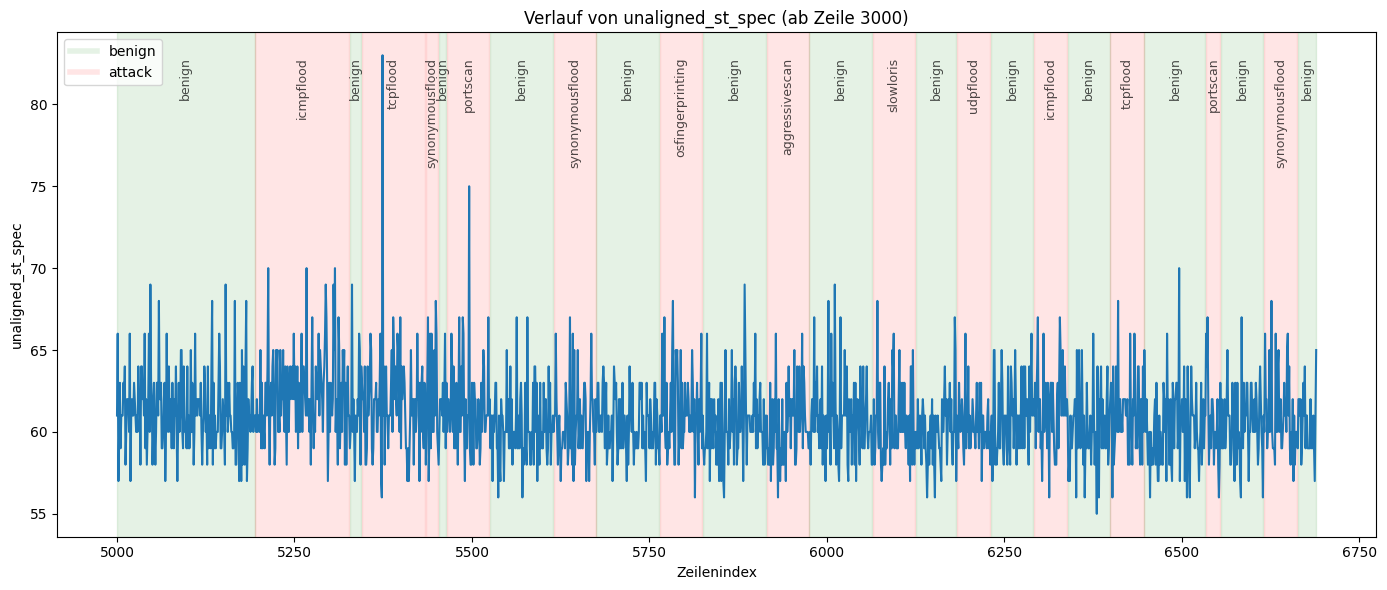

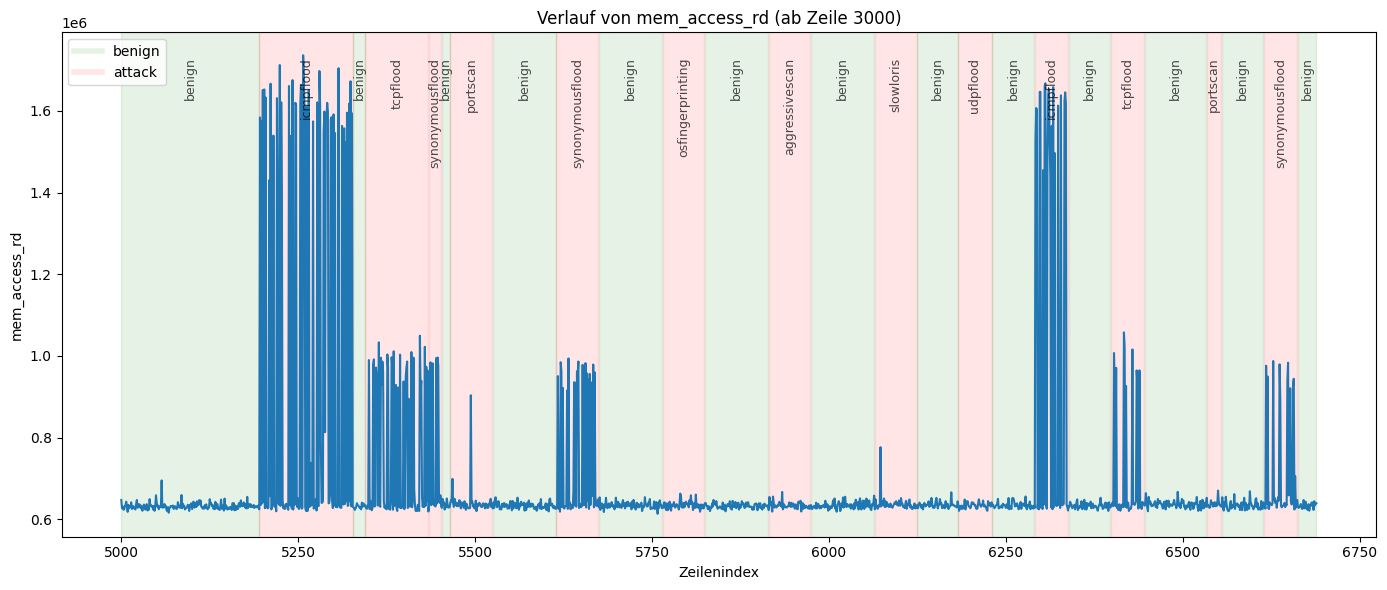

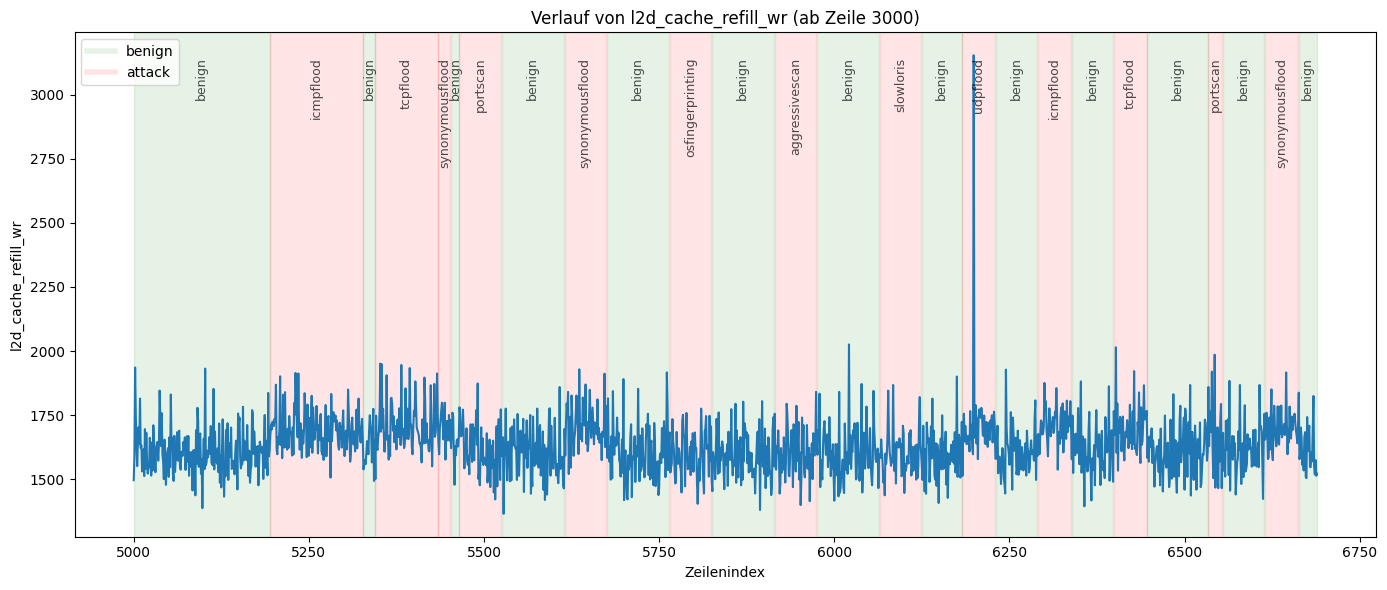

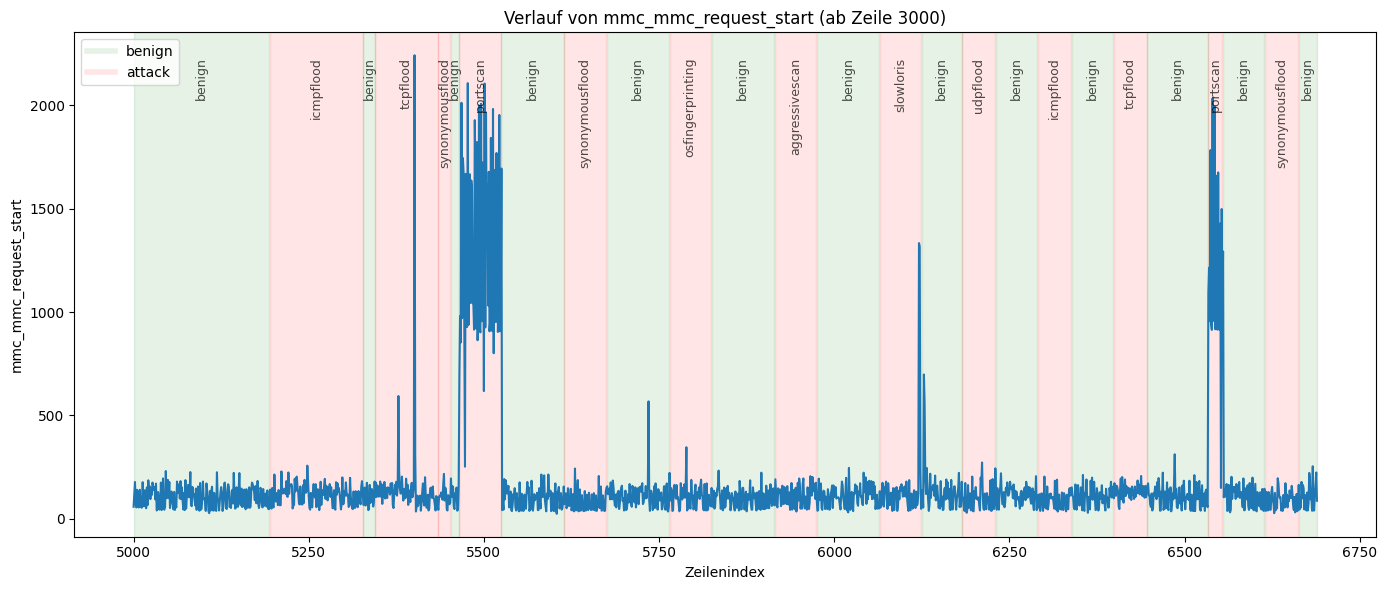

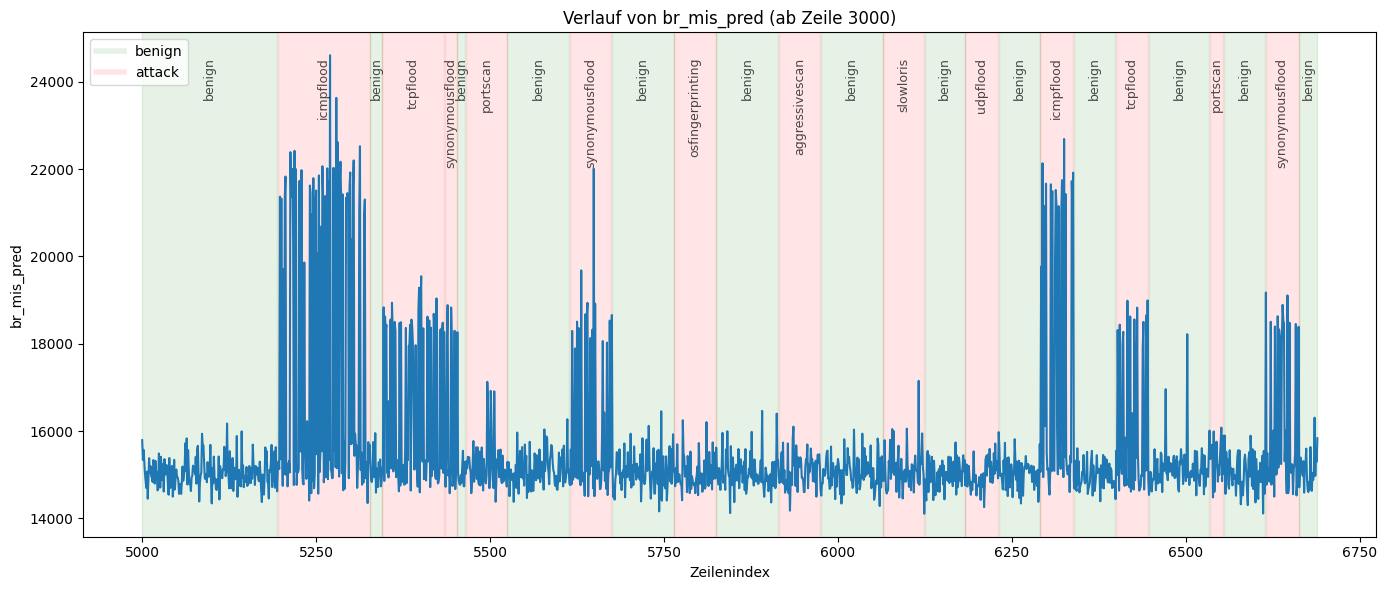

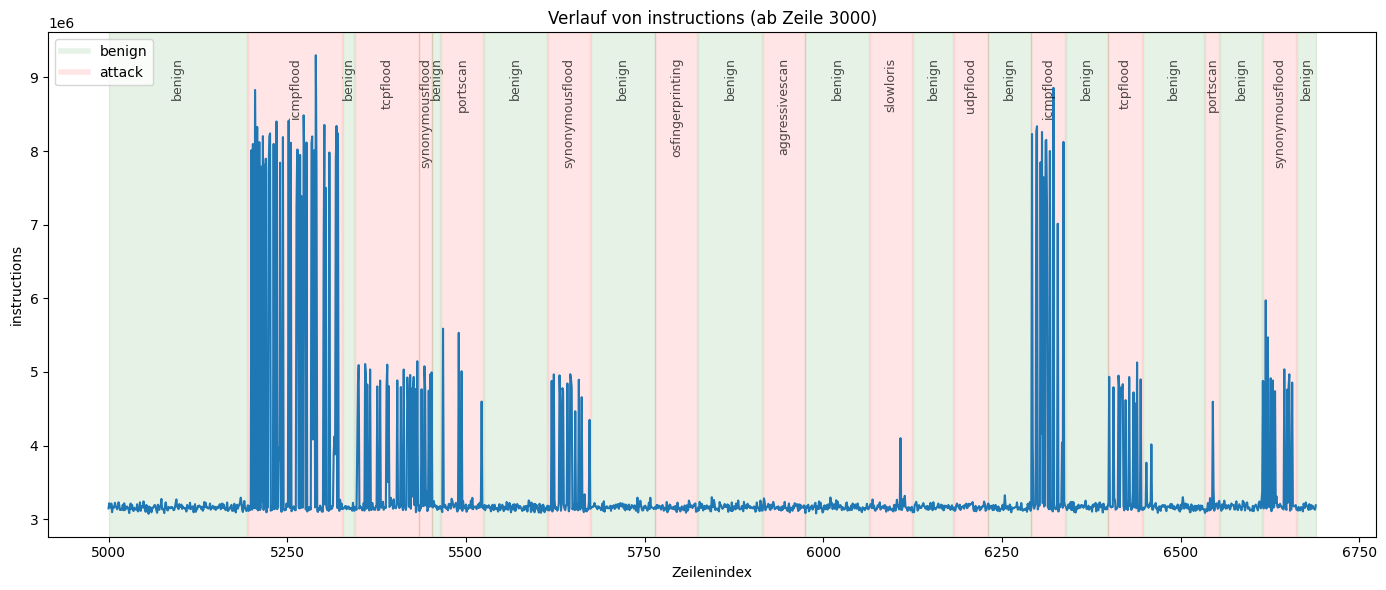

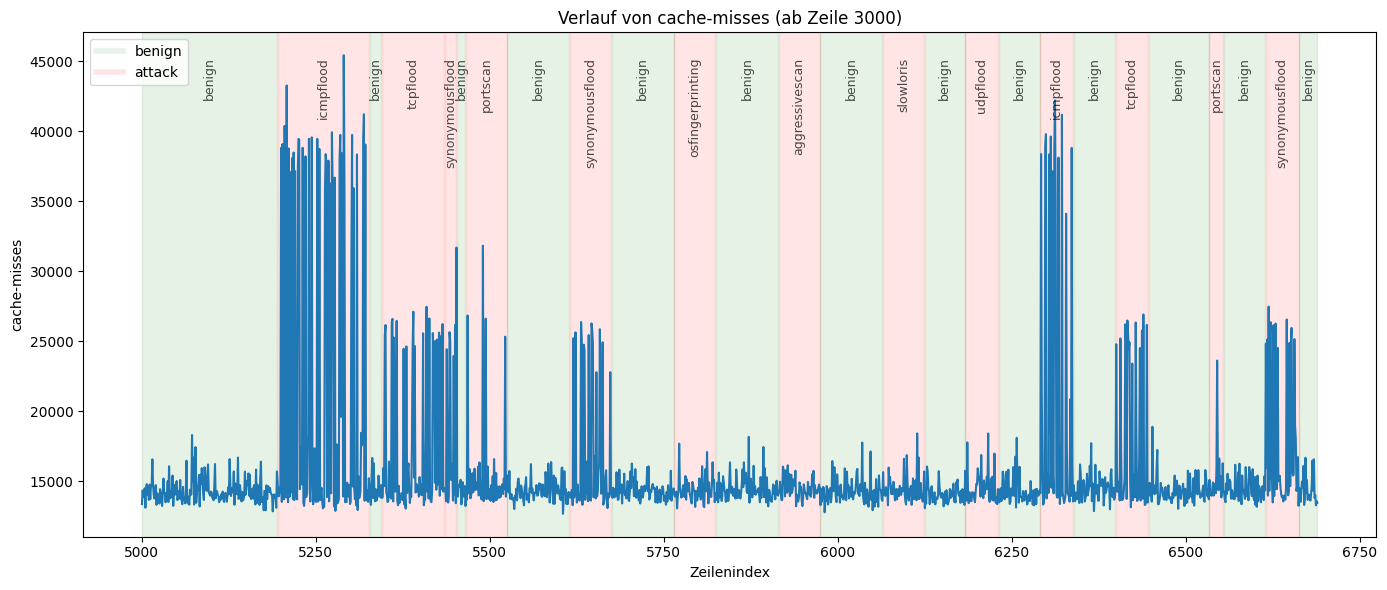

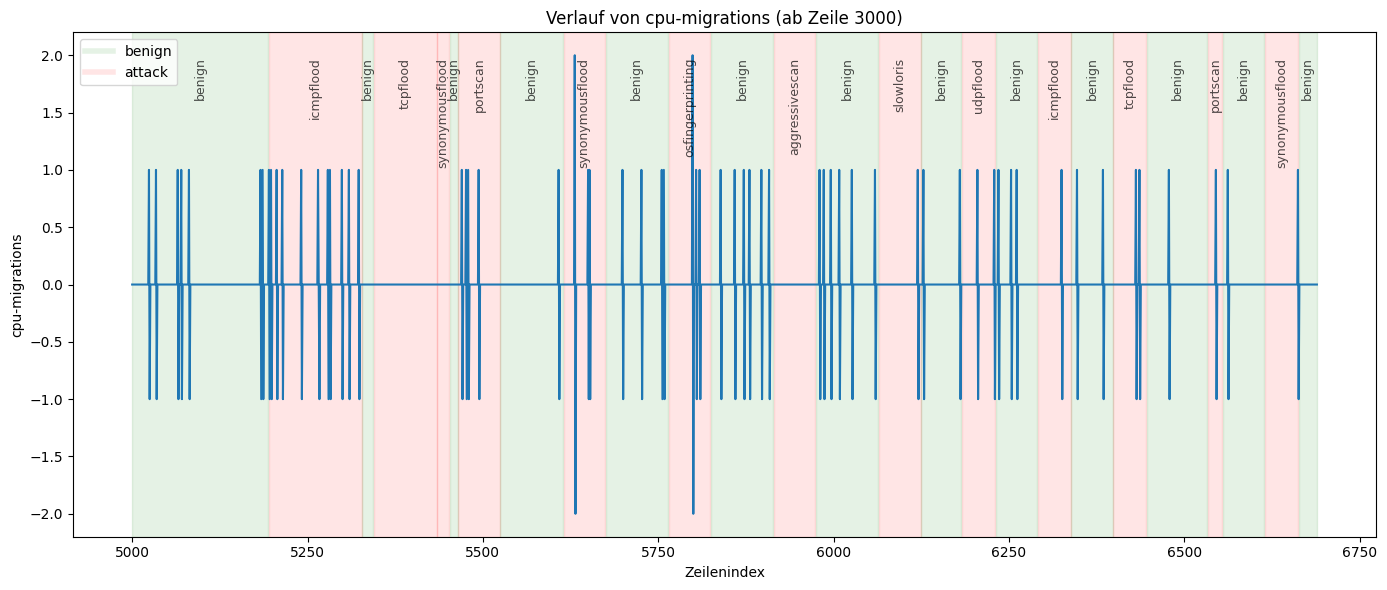

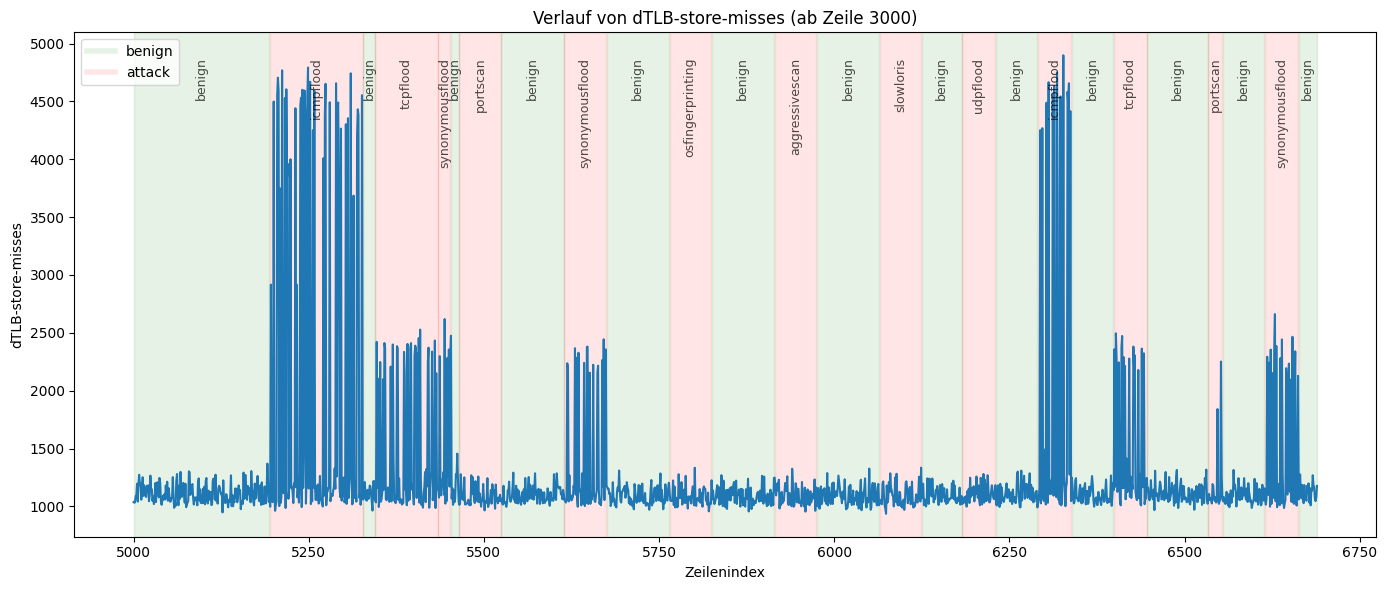

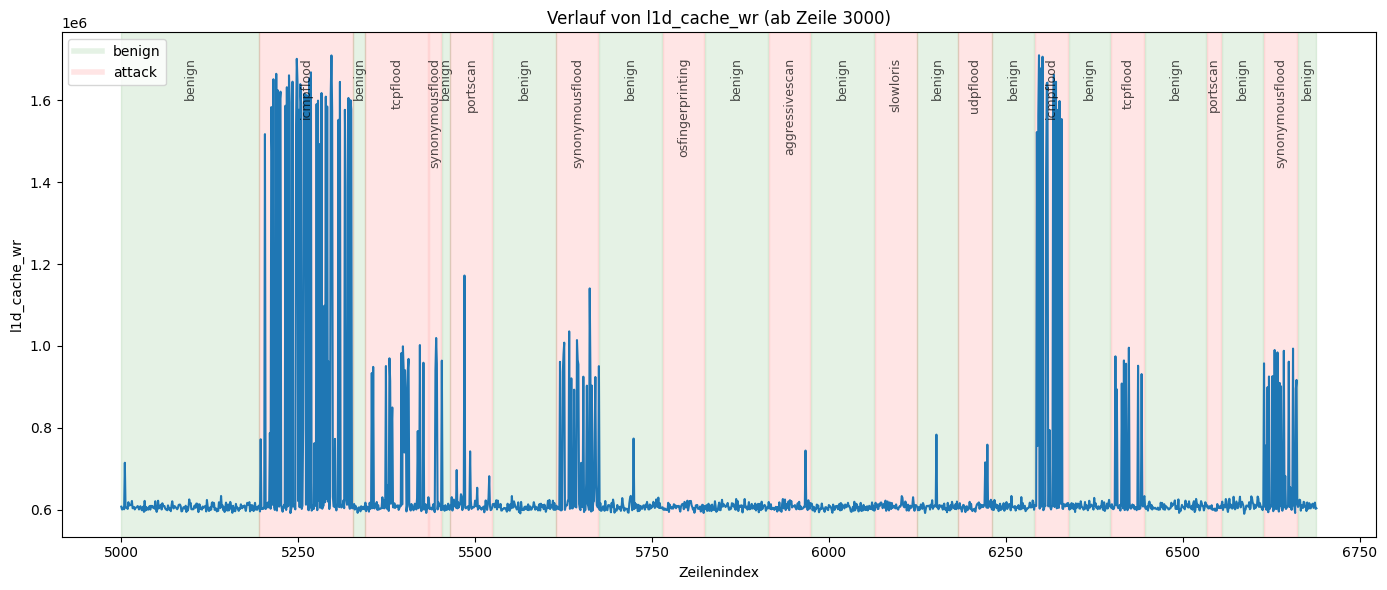

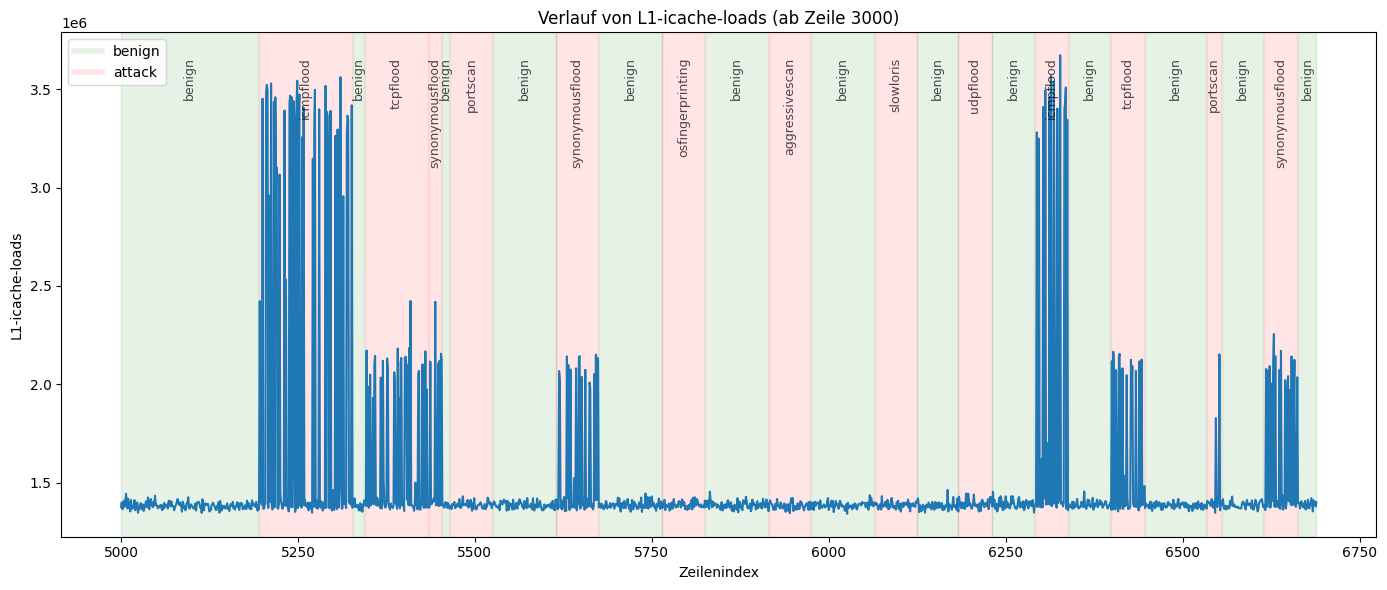

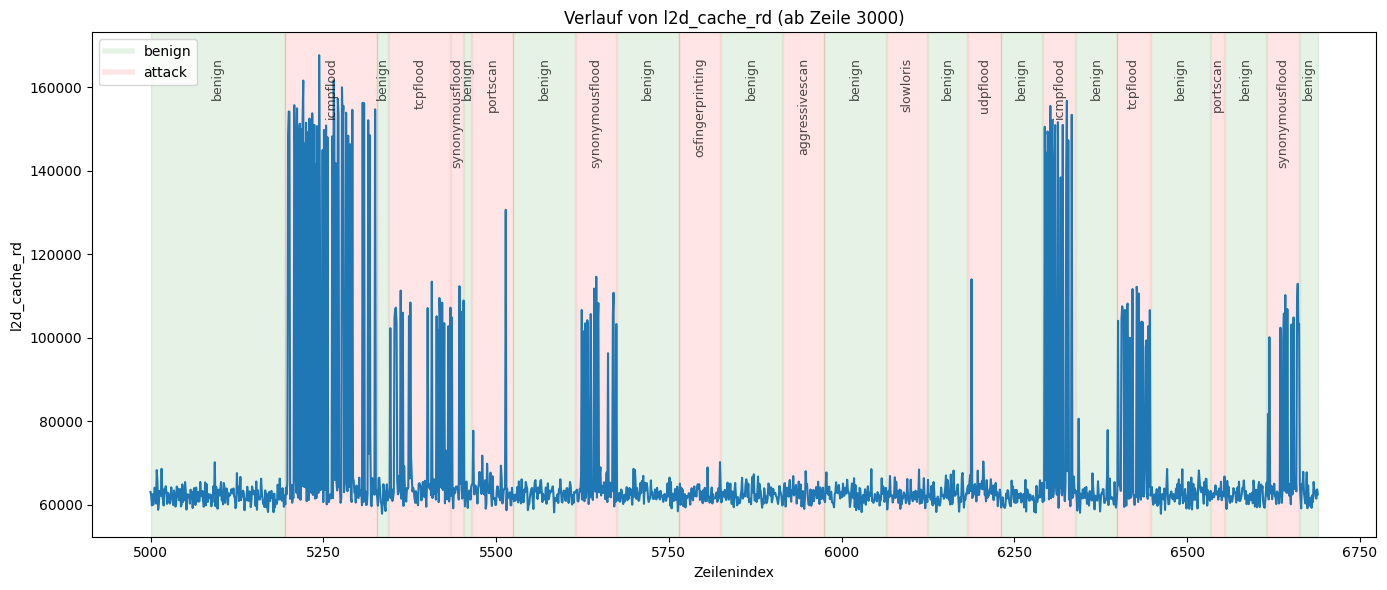

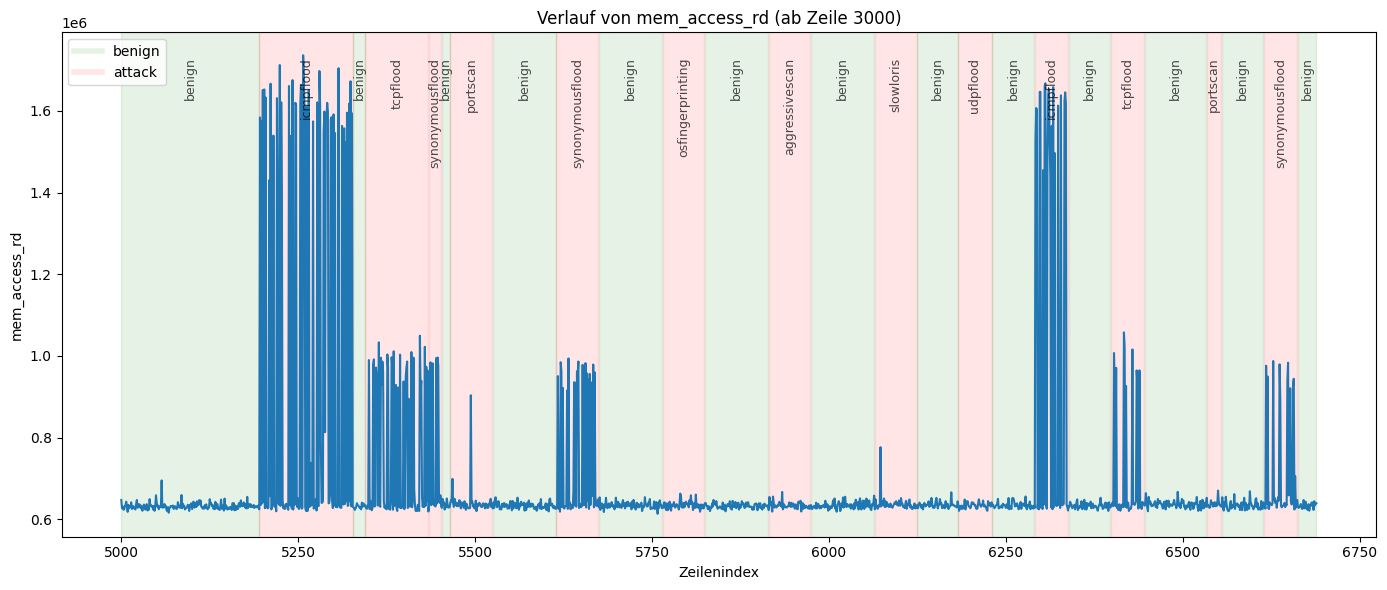

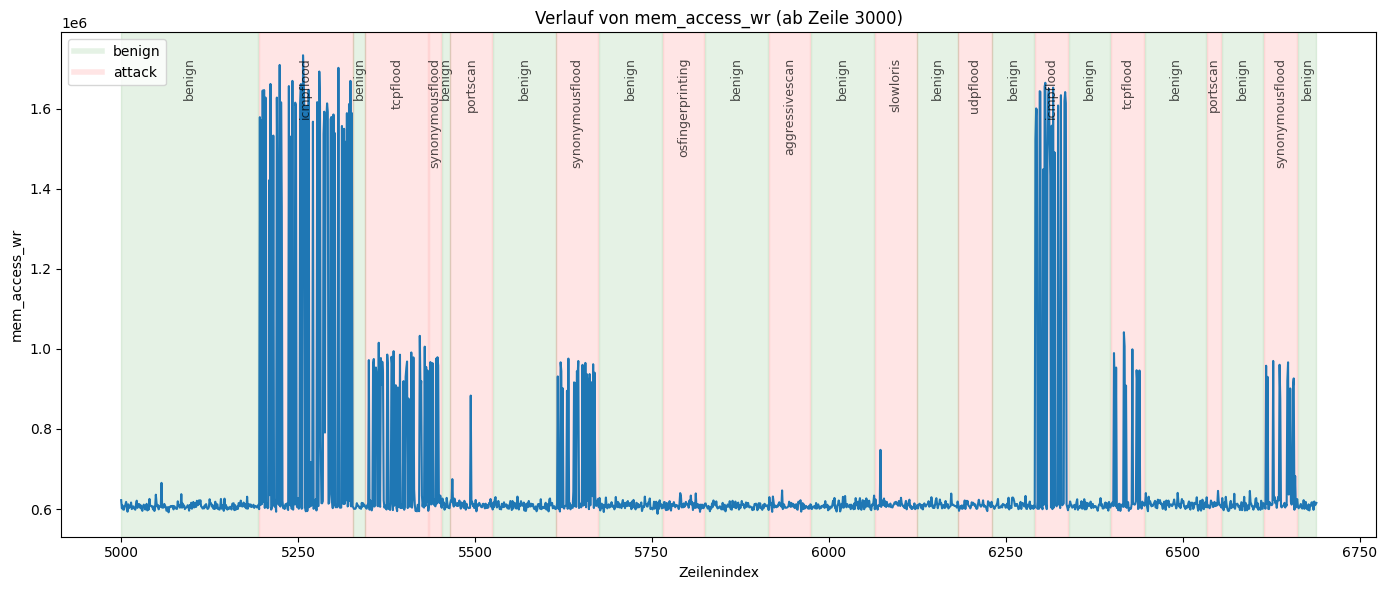

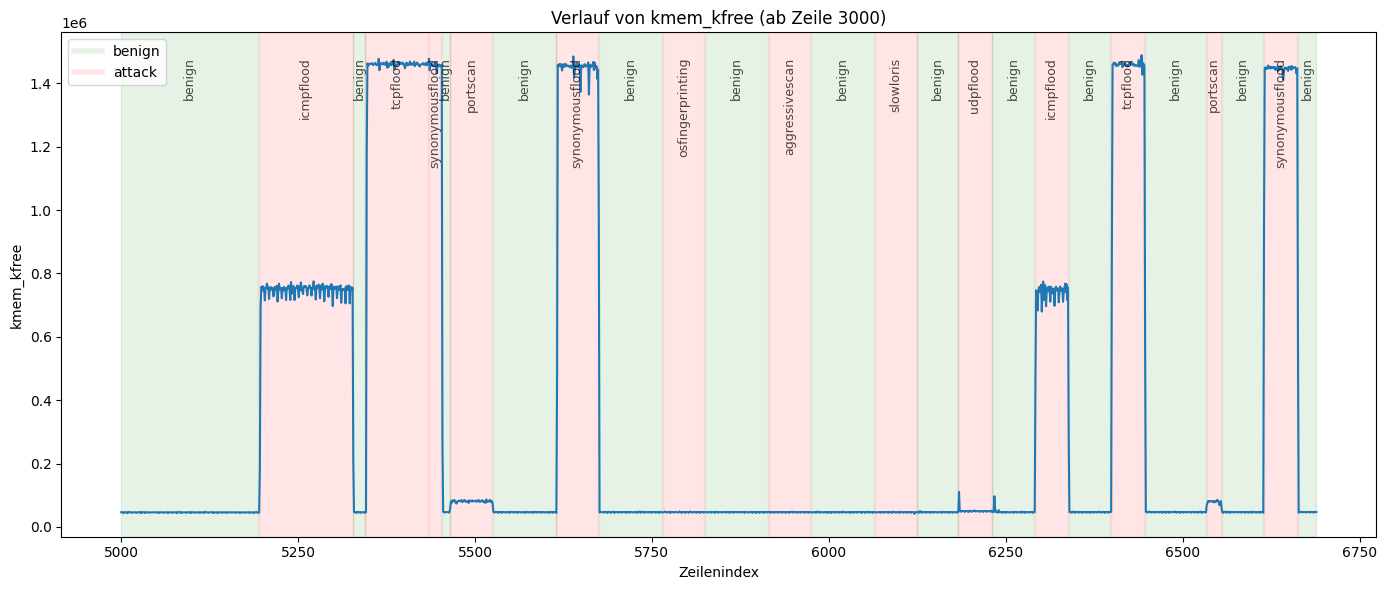

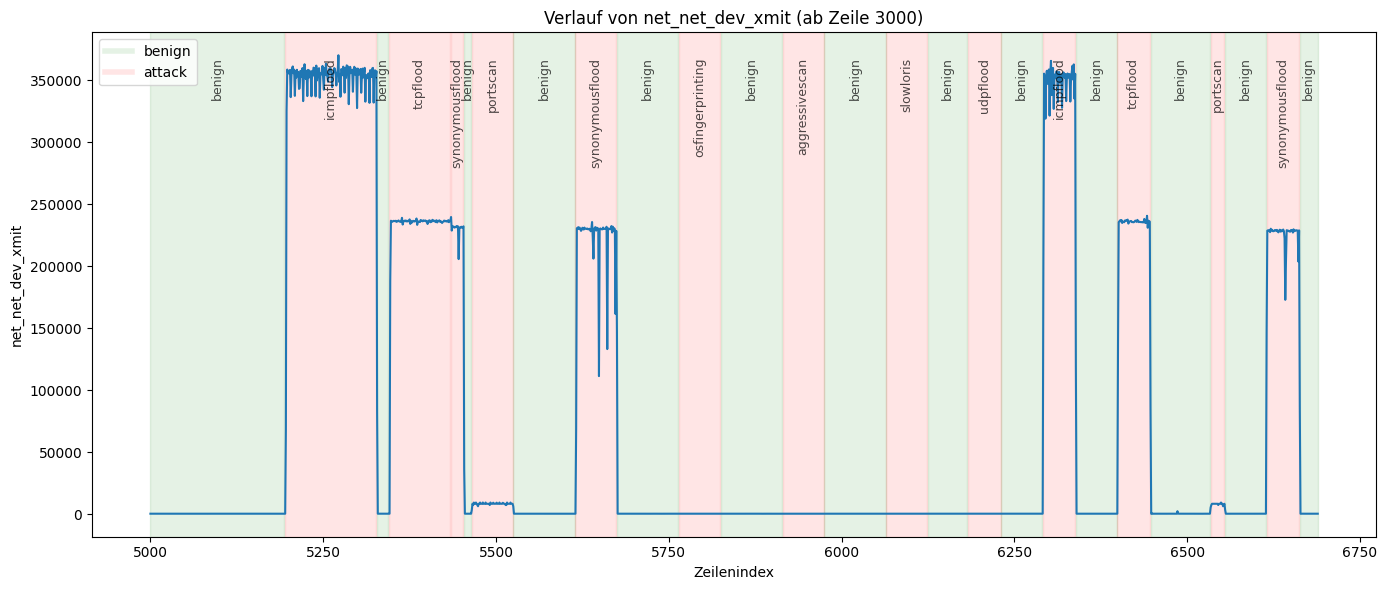

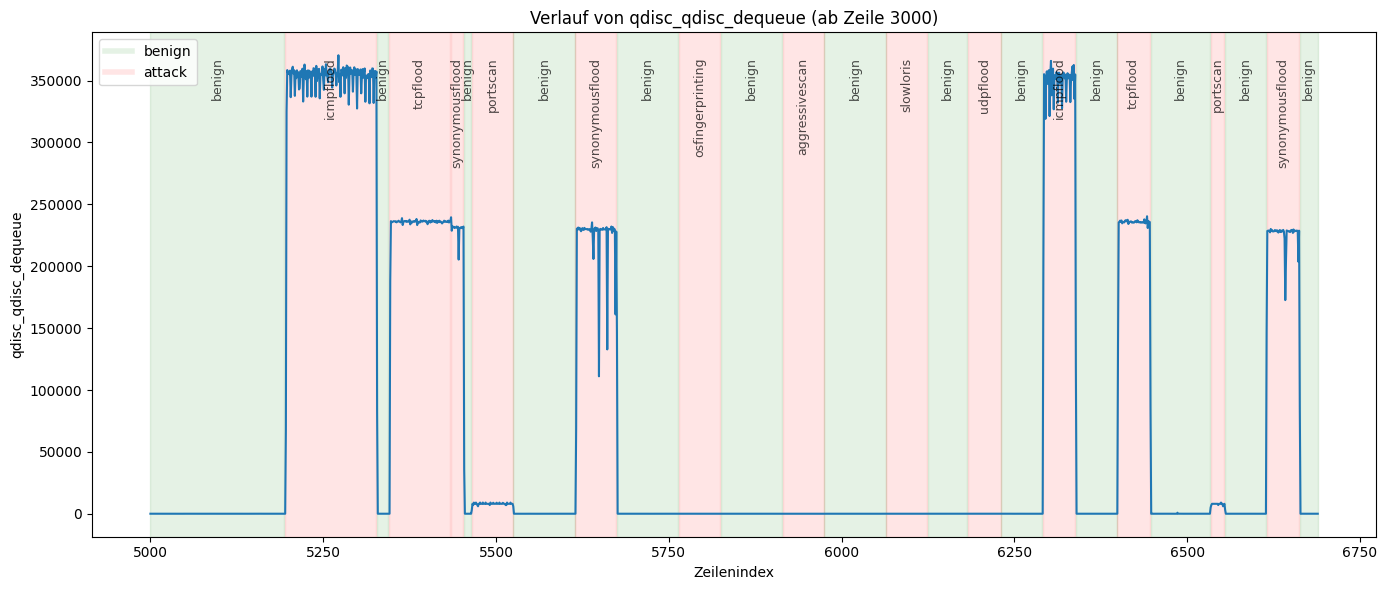

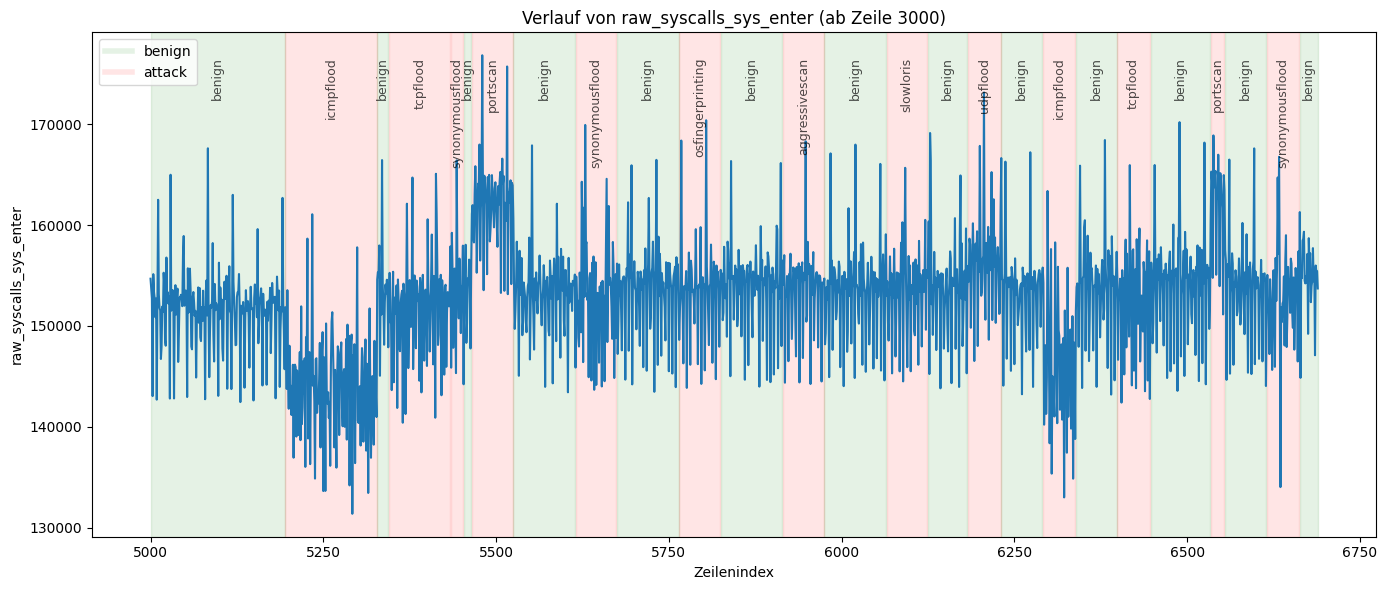

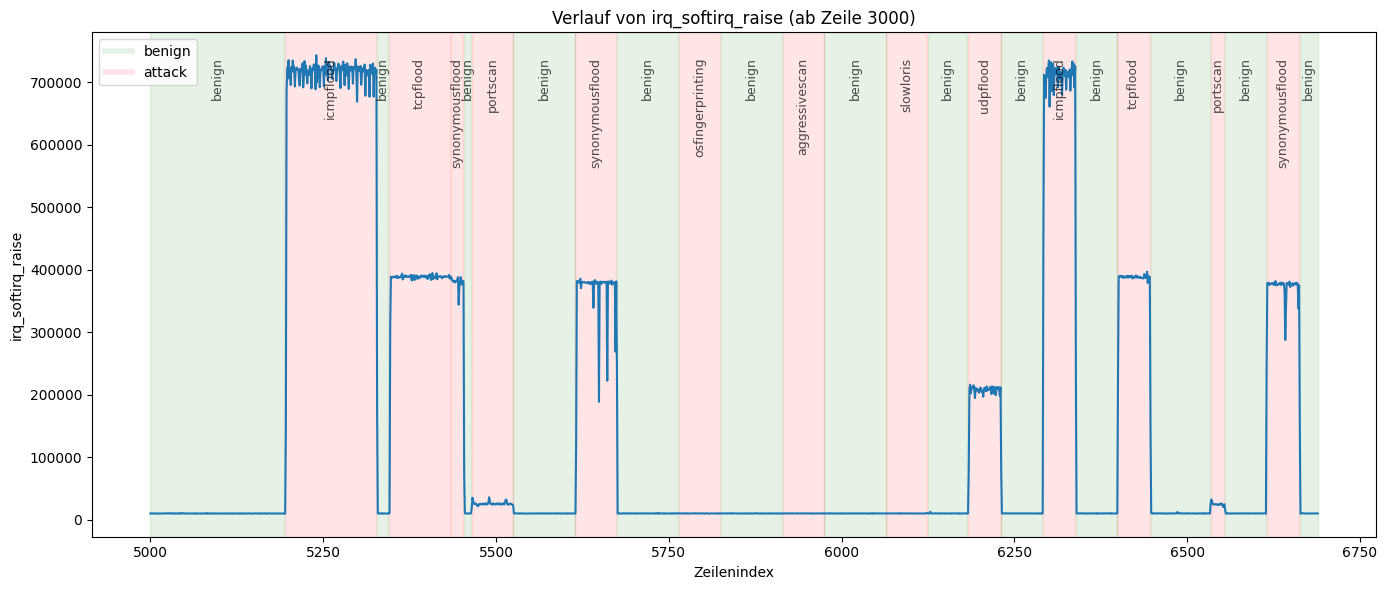

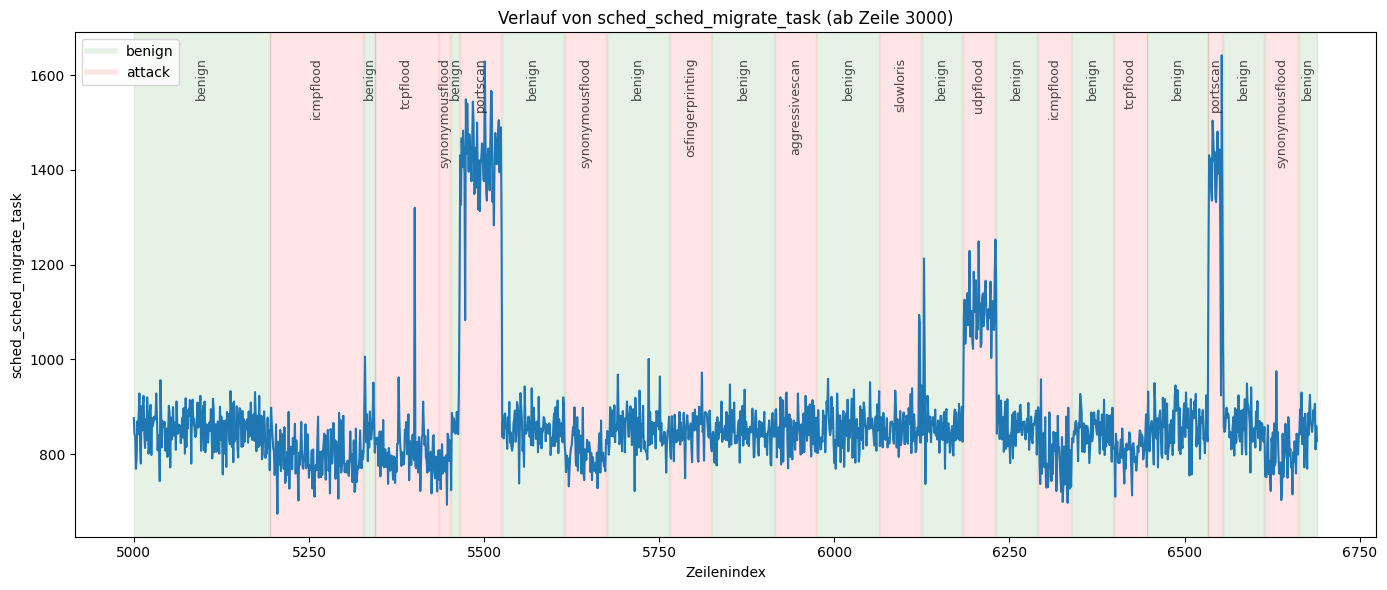

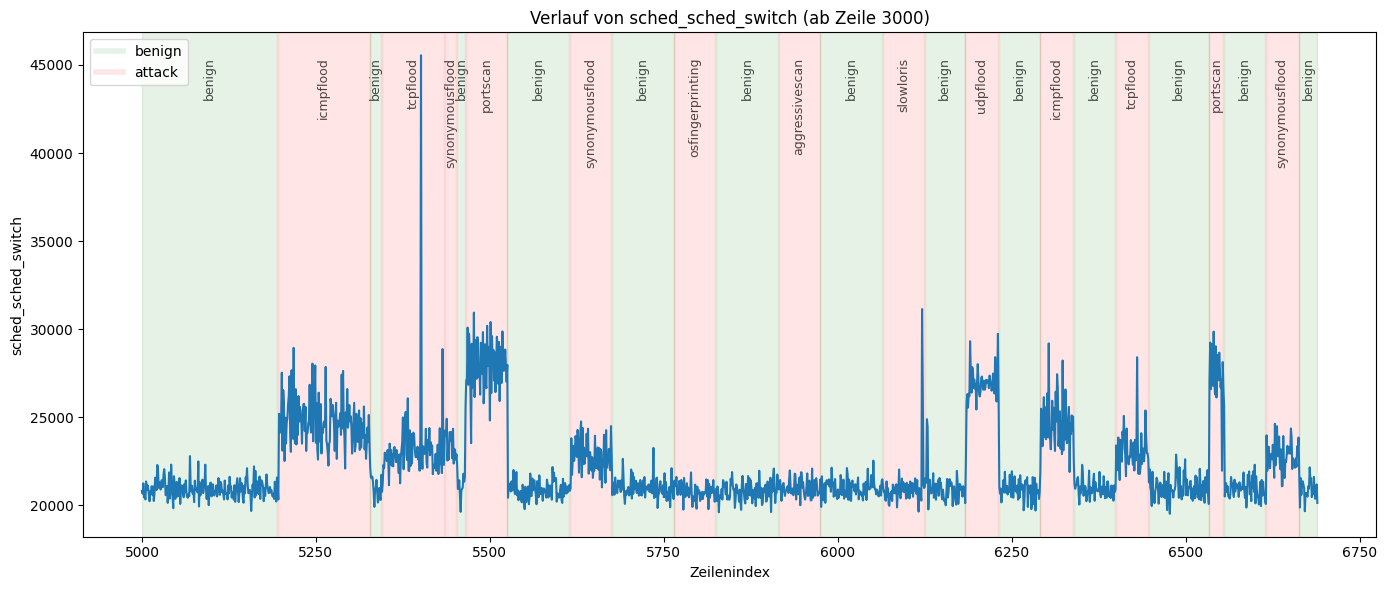

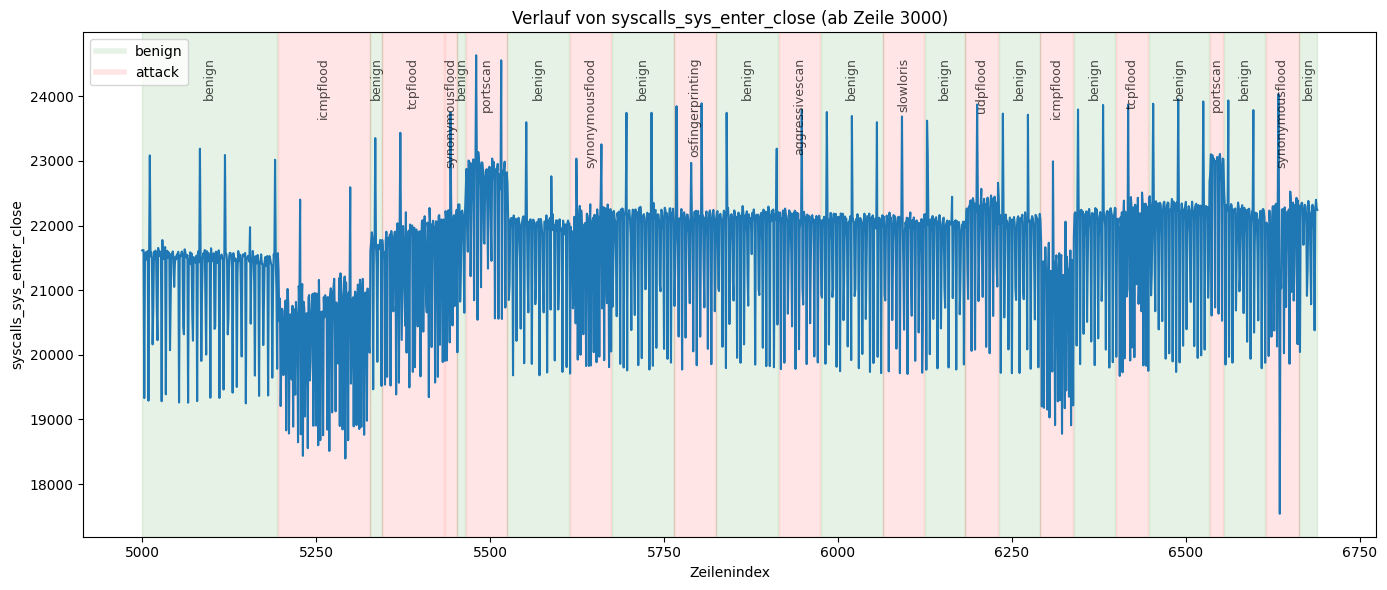

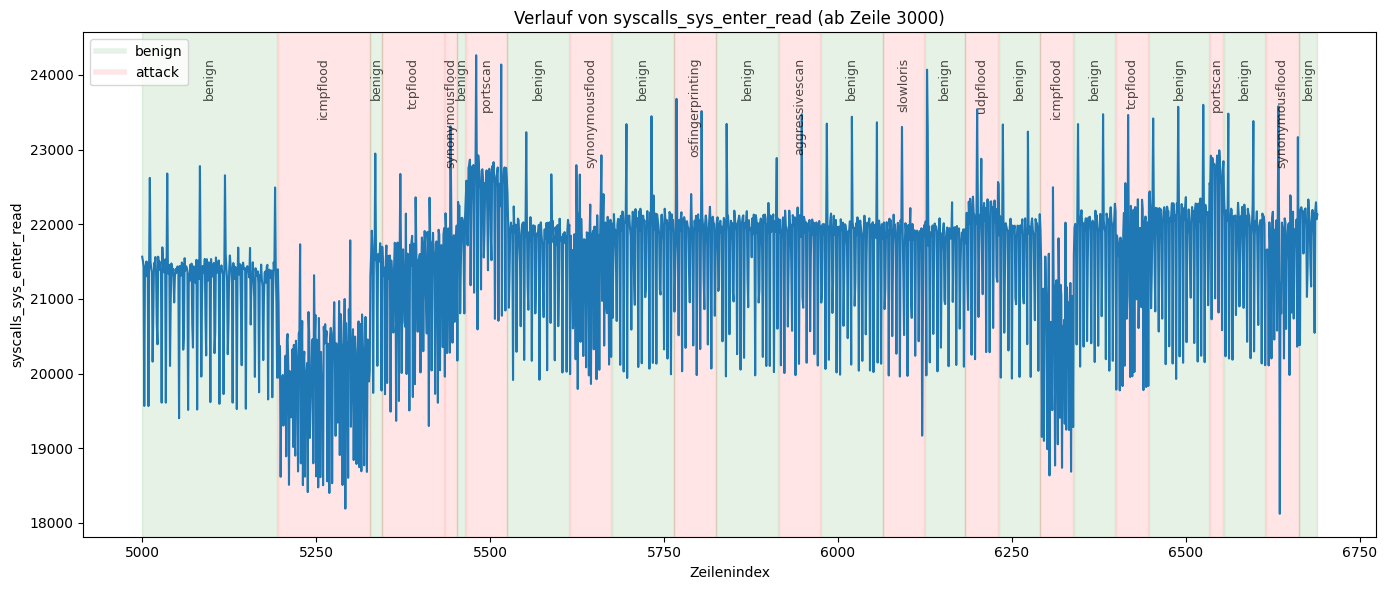

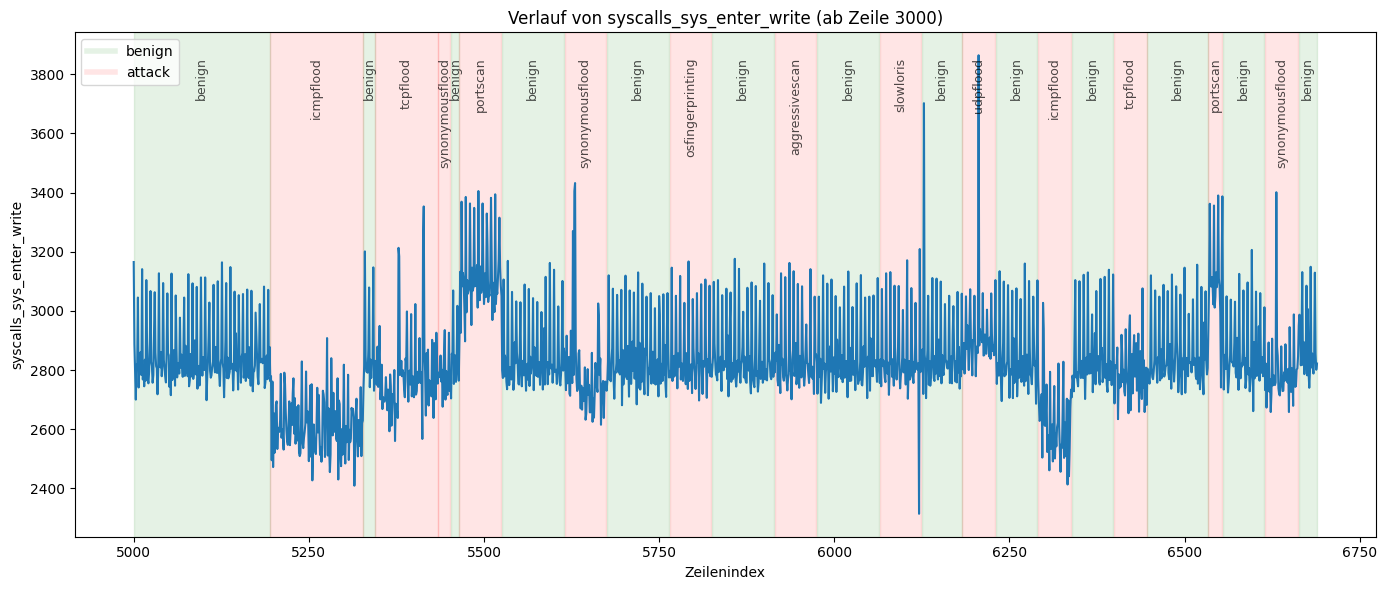

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = top20_features

for feat in selected_features:
    plt.figure(figsize=(14, 6))
    plt.plot(df_subset.index, df_subset[feat], label=feat)
    
    ymin, ymax = plt.ylim()
    start_idx = 0
    current_label = df_subset['Label'].iloc[0]
    current_attack = df_subset['attack'].iloc[0]

    for i in range(1, len(df_subset)):
        label_changed = df_subset['Label'].iloc[i] != current_label
        attack_changed = df_subset['attack'].iloc[i] != current_attack
        if label_changed or attack_changed:
            color = 'green' if current_label == 'benign' else 'red'
            plt.axvspan(df_subset.index[start_idx], df_subset.index[i-1], color=color, alpha=0.1)
            mid_pos = (df_subset.index[start_idx] + df_subset.index[i-1]) / 2
            plt.text(
                mid_pos,
                ymax - (ymax - ymin) * 0.05,
                current_attack,
                ha='center',
                va='top',
                fontsize=9,
                color='black',
                alpha=0.7,
                rotation=90
            )
            start_idx = i
            current_label = df_subset['Label'].iloc[i]
            current_attack = df_subset['attack'].iloc[i]

    # Letztes Segment einfärben und beschriften
    color = 'green' if current_label == 'benign' else 'red'
    plt.axvspan(df_subset.index[start_idx], df_subset.index[-1], color=color, alpha=0.1)
    mid_pos = (df_subset.index[start_idx] + df_subset.index[-1]) / 2
    plt.text(
        mid_pos,
        ymax - (ymax - ymin) * 0.05,
        current_attack,
        ha='center',
        va='top',
        fontsize=9,
        color='black',
        alpha=0.7,
        rotation=90
    )

    plt.title(f'Verlauf von {feat} (ab Zeile 3000)')
    plt.xlabel('Zeilenindex')
    plt.ylabel(feat)
    handles = [
        plt.Line2D([0], [0], color='green', lw=4, alpha=0.1, label='benign'),
        plt.Line2D([0], [0], color='red', lw=4, alpha=0.1, label='attack')
    ]
    plt.legend(handles=handles)
    plt.tight_layout()
    plt.show()


In [15]:
feature_plot = top20_features

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Optional: Output directory for the plots
output_dir = "feature_plots"
os.makedirs(output_dir, exist_ok=True)

selected_features = feature_plot

for feat in selected_features:
    plt.figure(figsize=(14, 6))
    plt.plot(df_subset.index, df_subset[feat], label=feat)

    ymin, ymax = plt.ylim()
    start_idx = 0
    current_label = df_subset['Label'].iloc[0]
    current_attack = df_subset['attack'].iloc[0]

    for i in range(1, len(df_subset)):
        label_changed = df_subset['Label'].iloc[i] != current_label
        attack_changed = df_subset['attack'].iloc[i] != current_attack
        if label_changed or attack_changed:
            color = 'green' if current_label == 'benign' else 'red'
            plt.axvspan(df_subset.index[start_idx], df_subset.index[i-1], color=color, alpha=0.1)
            mid_pos = (df_subset.index[start_idx] + df_subset.index[i-1]) / 2
            plt.text(
                mid_pos,
                ymax - (ymax - ymin) * 0.05,
                current_attack,
                ha='center',
                va='top',
                fontsize=9,
                color='black',
                alpha=0.7,
                rotation=90
            )
            start_idx = i
            current_label = df_subset['Label'].iloc[i]
            current_attack = df_subset['attack'].iloc[i]

    # Mark and label the last segment
    color = 'green' if current_label == 'benign' else 'red'
    plt.axvspan(df_subset.index[start_idx], df_subset.index[-1], color=color, alpha=0.1)
    mid_pos = (df_subset.index[start_idx] + df_subset.index[-1]) / 2
    plt.text(
        mid_pos,
        ymax - (ymax - ymin) * 0.05,
        current_attack,
        ha='center',
        va='top',
        fontsize=9,
        color='black',
        alpha=0.7,
        rotation=90
    )

    plt.title(f'Time series of {feat} (from row 5000 onward)')
    plt.xlabel('Row index')
    plt.ylabel(feat)
    handles = [
        plt.Line2D([0], [0], color='green', lw=4, alpha=0.1, label='benign'),
        plt.Line2D([0], [0], color='red', lw=4, alpha=0.1, label='attack')
    ]
    plt.legend(handles=handles)
    plt.tight_layout()

    # Save the plot as PNG
    filename = f"{feat.replace('/', '_')}.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300)
    plt.close()  # Free memory, do not show the plot


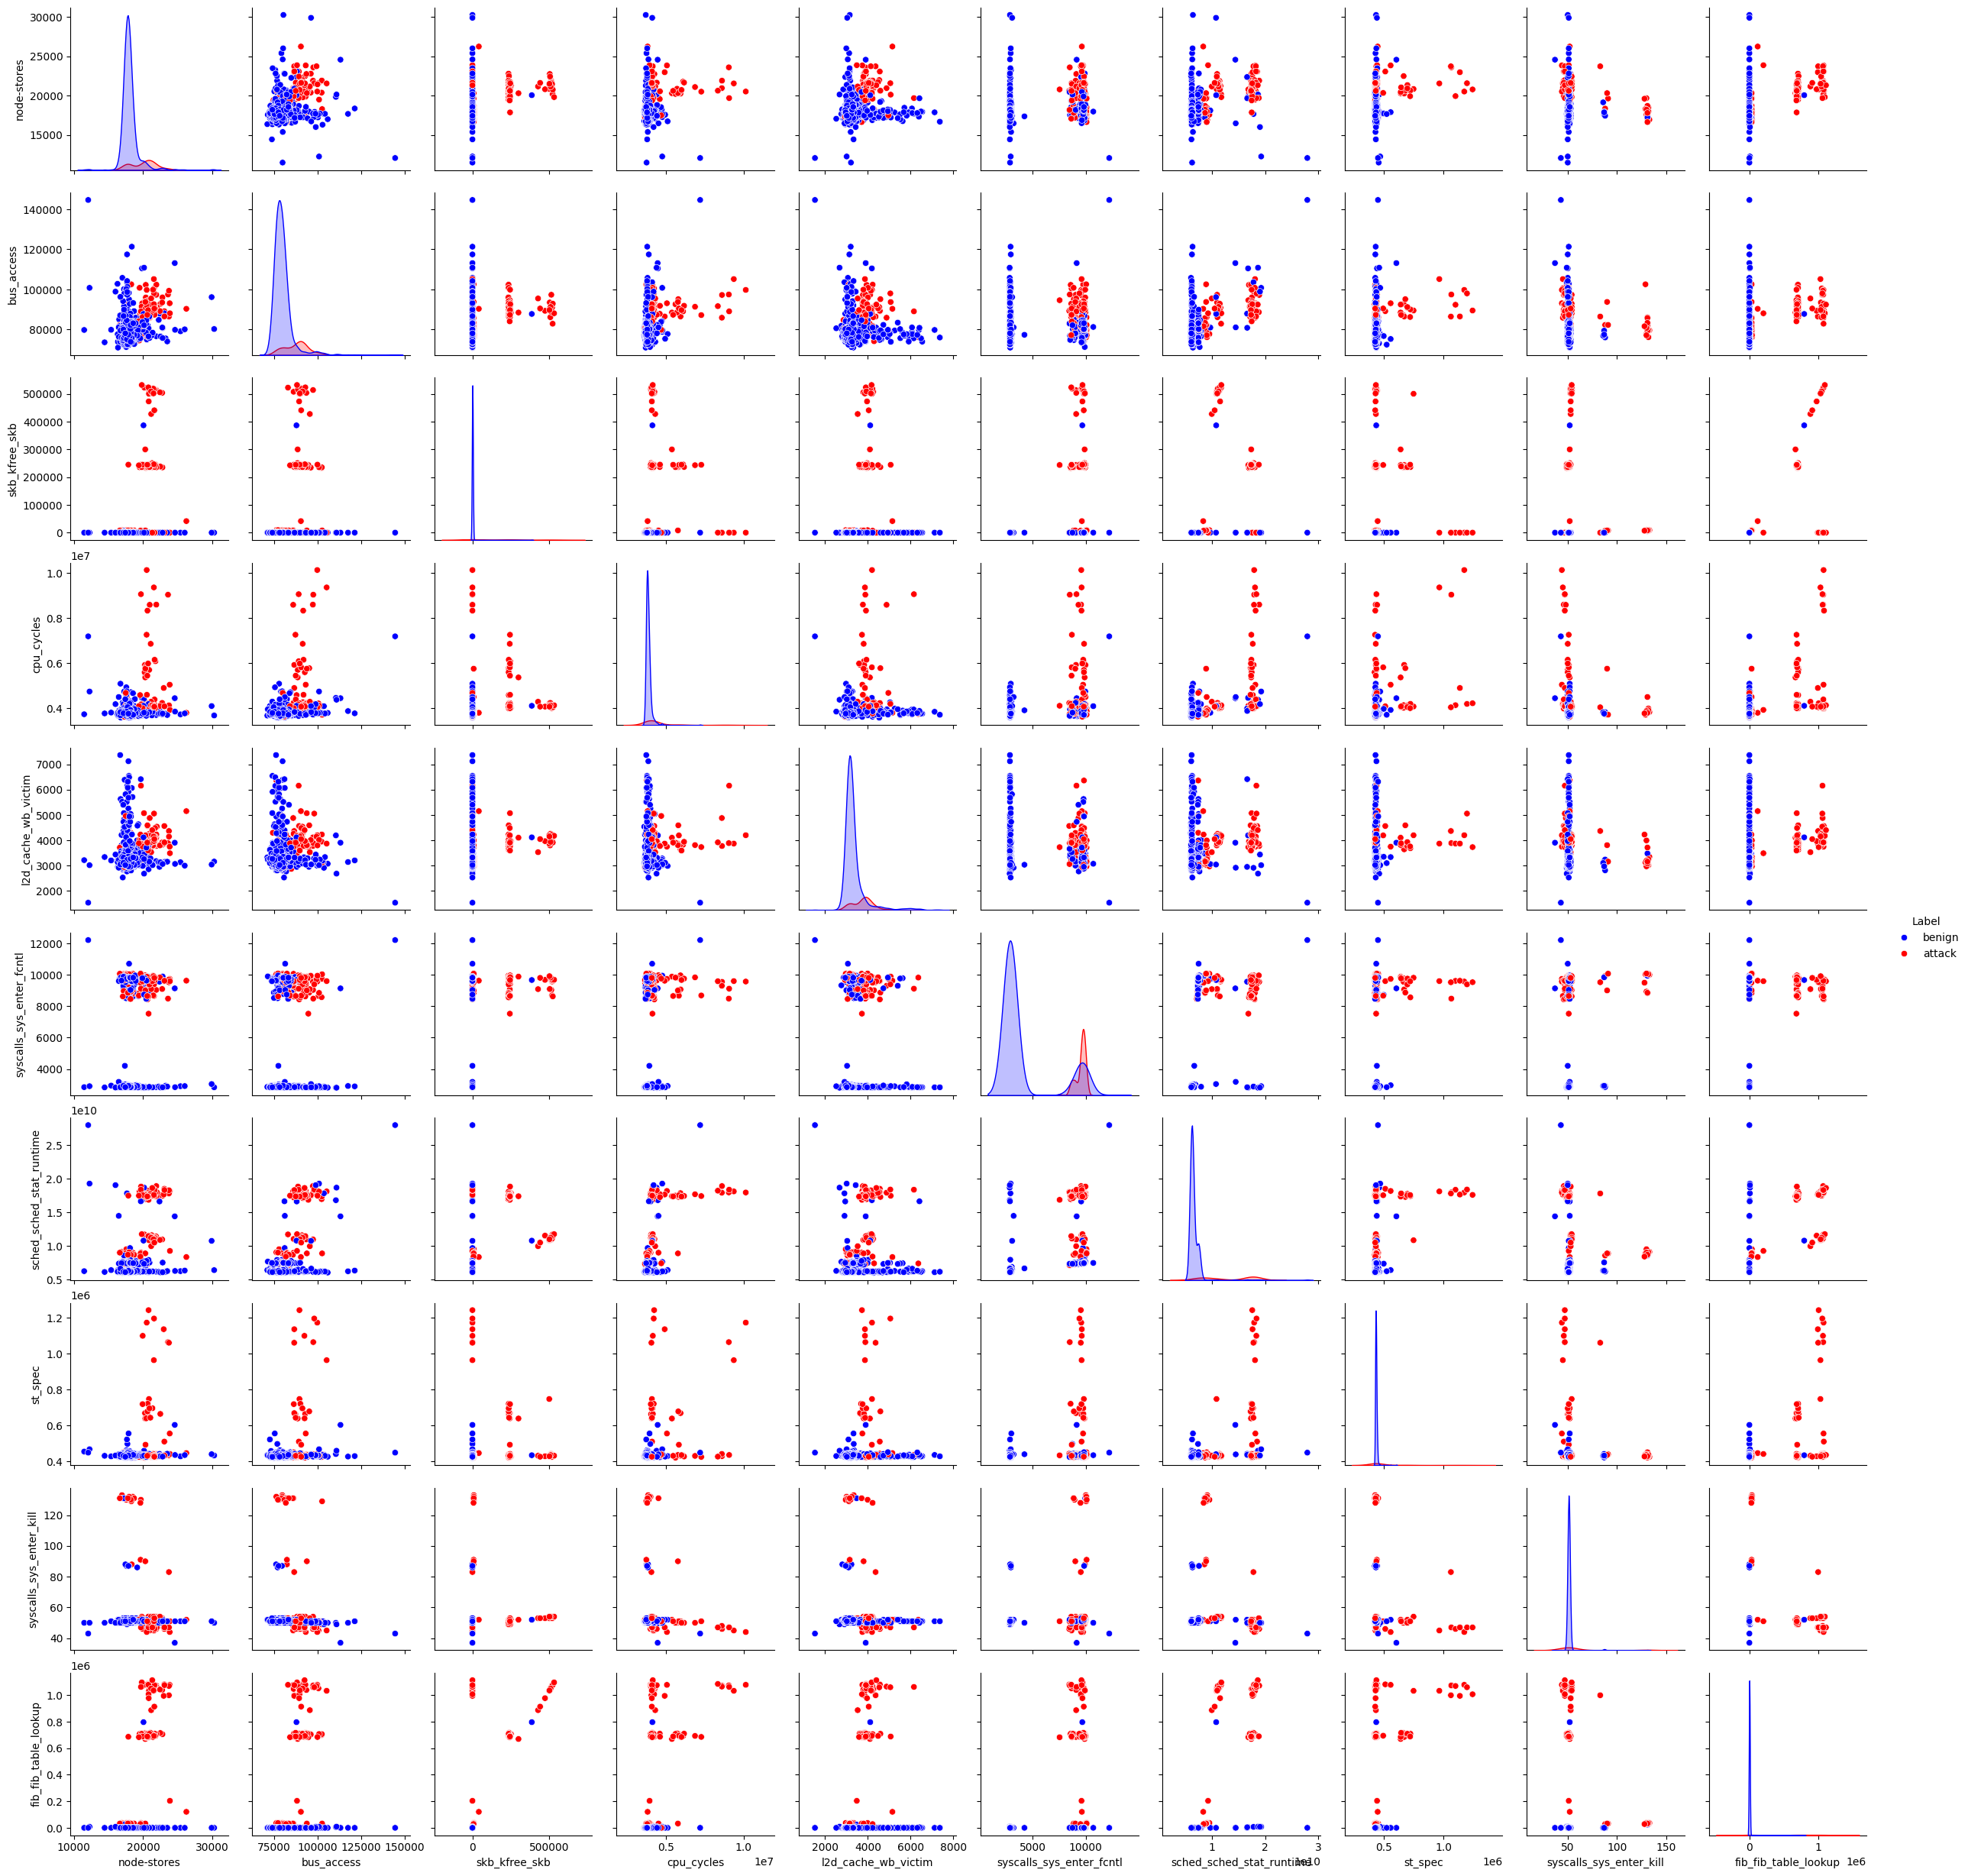

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Beispiel: "benign" = blau, "attack" = rot
palette = {'benign': 'blue', 'attack': 'red'}

sample_df = df[top20_features[:10] + ['Label']].sample(n=min(1000, len(df)), random_state=42)
sns.pairplot(sample_df, hue='Label', palette=palette)
plt.show()
